<a href="https://colab.research.google.com/github/Edwinlinks/intensity_correction_test/blob/main/seg_improve.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install open3d matplotlib scikit-learn scipy numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.7/447.7 MB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 97.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 78.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 57.7 MB/s eta 0:00:00
  Attempting uninstall: widgetsnbextension
    Found existing installation: widgetsnbextension 3.6.10
    Uninstalling widgetsnbextension-3.6.10:
      Successfully uninstalled widgetsnbextension-3.6.10
  Attempting uninstall: ipywidgets
    Found existing installation: ipywidgets 7.7.1
    Uninstalling ipywidgets-7.7.1:
      Successfully uninstalled ipywidgets-7.7.1


生成的电塔点云包含 31236 个点


/tmp/ipython-input-3-2029464318.py:469: UserWarning: Glyph 21333 (\N{CJK UNIFIED IDEOGRAPH-5355}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3-2029464318.py:469: UserWarning: Glyph 20010 (\N{CJK UNIFIED IDEOGRAPH-4E2A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3-2029464318.py:469: UserWarning: Glyph 30005 (\N{CJK UNIFIED IDEOGRAPH-7535}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3-2029464318.py:469: UserWarning: Glyph 22612 (\N{CJK UNIFIED IDEOGRAPH-5854}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3-2029464318.py:469: UserWarning: Glyph 32467 (\N{CJK UNIFIED IDEOGRAPH-7ED3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3-2029464318.py:469: UserWarning: Glyph 26500 (\N{CJK UNIFIED IDEOGRAPH-6784}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarnin

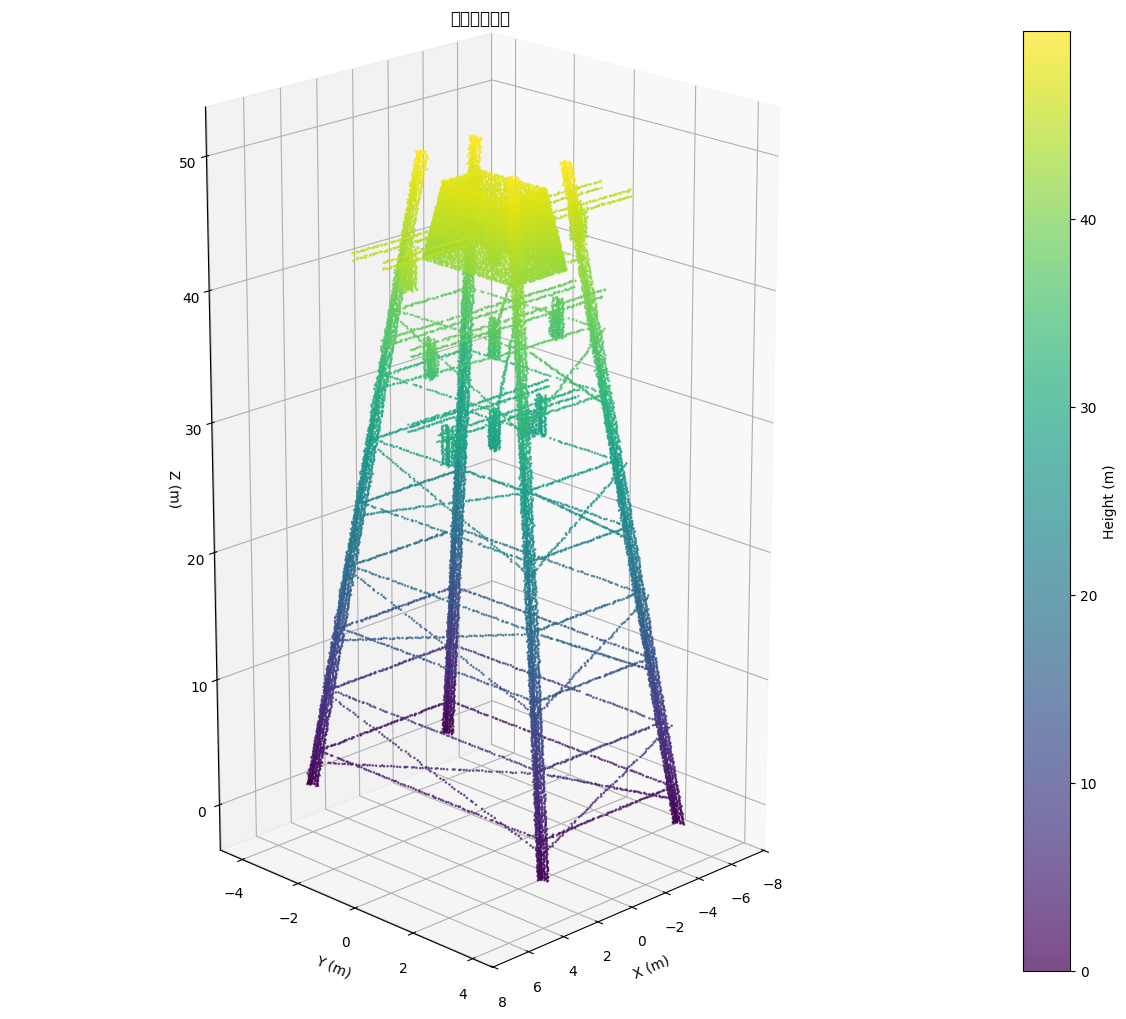

生成的场景包含 93708 个点


/tmp/ipython-input-3-2029464318.py:469: UserWarning: Glyph 22810 (\N{CJK UNIFIED IDEOGRAPH-591A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3-2029464318.py:469: UserWarning: Glyph 22330 (\N{CJK UNIFIED IDEOGRAPH-573A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3-2029464318.py:469: UserWarning: Glyph 26223 (\N{CJK UNIFIED IDEOGRAPH-666F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 22810 (\N{CJK UNIFIED IDEOGRAPH-591A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 22330 (\N{CJK UNIFIED IDEOGRAPH-573A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 26223 (\N{CJK UNIFIED IDEOGRAPH-666F})

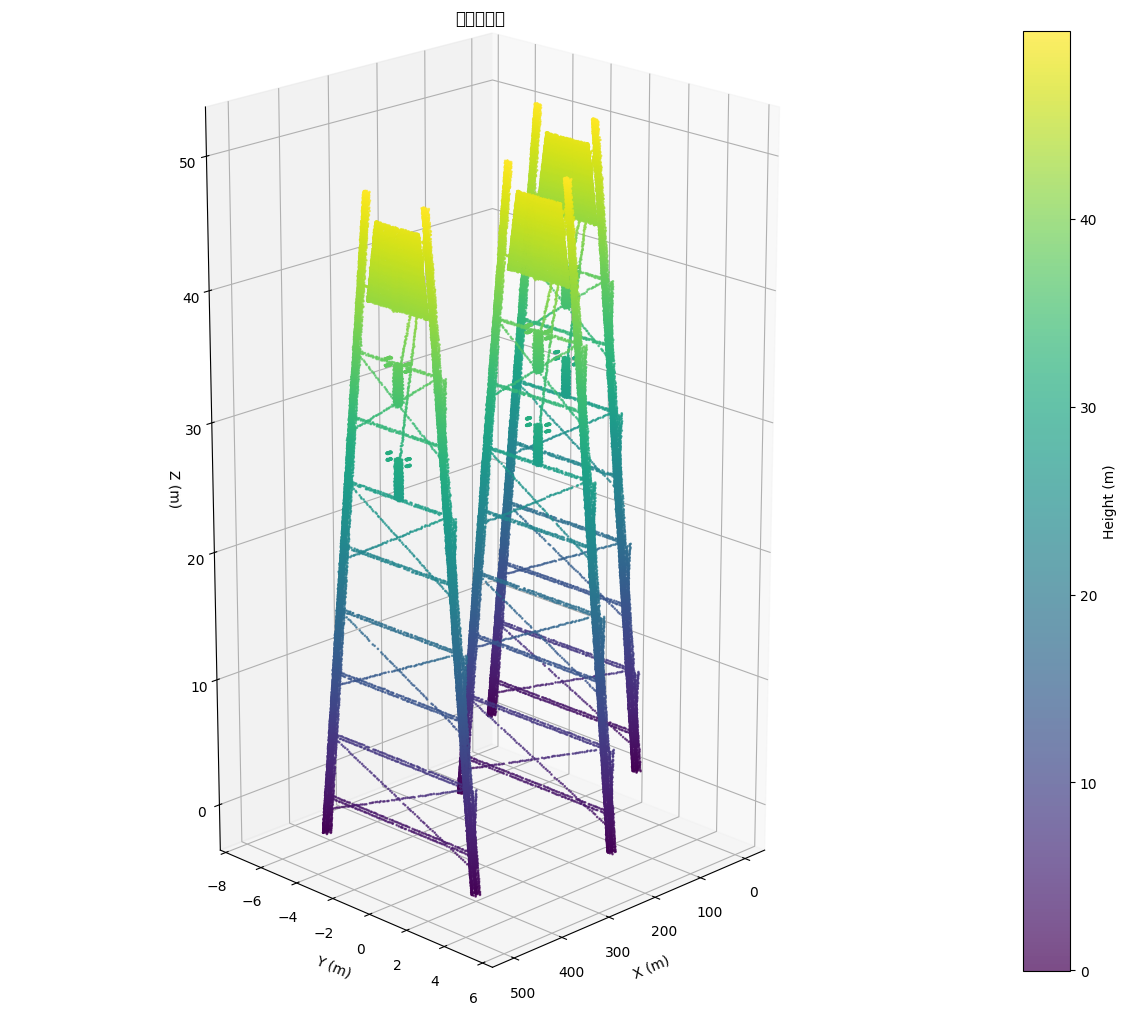

改进的数据集生成完成！
主要改进:
1. 塔身与塔头平滑过渡
2. 横担与塔身连接结构
3. 更真实的角钢结构模拟
4. 改进的噪声模型
5. 更合理的绝缘子串设计


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import open3d as o3d
from typing import List, Tuple
import json

class ImprovedTowerGenerator:
    """改进的电塔点云生成器"""

    def __init__(self, config: dict = None):
        self.config = config or self._default_config()

    def _default_config(self) -> dict:
        return {
            'tower_height': 50.0,
            'tower_width_base': 8.0,
            'tower_width_top': 3.0,
            'crossarm_lengths': [14.0, 11.0, 8.0],  # 横担长度从上到下递减
            'crossarm_heights': [45.0, 38.0, 31.0],  # 横担高度
            'crossarm_width': 1.0,  # 横担宽度
            'insulator_count': 3,  # 每层绝缘子数量
            'conductor_span': 200.0,
            'point_density': 0.08,  # 点密度
            'noise_level': 0.015,    # 噪声水平
            'missing_data_ratio': 0.05,  # 缺失数据比例
            'leg_thickness': 0.3,  # 塔腿厚度
        }

    def generate_tower_structure(self, tower_id: int = 0) -> np.ndarray:
        """生成完整的电塔结构点云"""
        points = []

        # 1. 生成塔身主结构
        points.extend(self._generate_tower_legs())

        # 2. 生成塔身连接支撑
        points.extend(self._generate_tower_bracing())

        # 3. 生成塔头过渡部分
        points.extend(self._generate_tower_head_transition())

        # 4. 生成横担及其支撑
        points.extend(self._generate_crossarm_assembly())

        # 5. 生成绝缘子串
        points.extend(self._generate_insulator_strings())

        # 6. 生成导线悬挂点
        points.extend(self._generate_conductor_attachment_points())

        # 7. 添加真实噪声
        points = np.array(points)
        points = self._add_realistic_noise(points)

        return points

    def _generate_tower_legs(self) -> List[np.ndarray]:
        """生成塔腿 - 四根主要支柱，确保平滑过渡"""
        points = []
        height = self.config['tower_height']
        base_width = self.config['tower_width_base']
        top_width = self.config['tower_width_top']
        leg_thickness = self.config['leg_thickness']

        # 四根塔腿的基本位置
        leg_positions = [
            (1, 1),   # 右前
            (-1, 1),  # 左前
            (-1, -1), # 左后
            (1, -1)   # 右后
        ]

        # 生成每根塔腿
        for leg_idx, (dx, dy) in enumerate(leg_positions):
            # 从底部到顶部的高度采样
            z_coords = np.arange(0, height, self.config['point_density'])

            for z in z_coords:
                # 计算当前高度的塔腿位置（线性插值）
                alpha = z / height
                current_width = base_width * (1 - alpha) + top_width * alpha

                # 基础位置
                base_x = dx * current_width / 2
                base_y = dy * current_width / 2

                # 为每根塔腿生成截面点（模拟角钢结构）
                # 生成L型截面
                for offset in self._generate_angle_steel_section(leg_thickness):
                    x = base_x + offset[0]
                    y = base_y + offset[1]

                    # 添加轻微的随机扰动
                    x += np.random.normal(0, 0.005)
                    y += np.random.normal(0, 0.005)

                    points.append([x, y, z])

        return points

    def _generate_angle_steel_section(self, thickness: float) -> List[Tuple[float, float]]:
        """生成角钢截面的点"""
        offsets = []
        step = thickness / 3

        # L型截面
        for i in range(3):
            offsets.append((i * step - thickness/2, -thickness/2))  # 水平部分
            offsets.append((-thickness/2, i * step - thickness/2))  # 垂直部分

        return offsets

    def _generate_tower_bracing(self) -> List[np.ndarray]:
        """生成塔身支撑结构"""
        points = []
        height = self.config['tower_height']
        base_width = self.config['tower_width_base']
        top_width = self.config['tower_width_top']

        # 水平支撑 - 每5米一层
        for z in np.arange(3, height - 5, 5):
            alpha = z / height
            current_width = base_width * (1 - alpha) + top_width * alpha

            # 四边的水平支撑
            for side in range(4):
                if side == 0:  # 前边
                    x_coords = np.linspace(-current_width/2, current_width/2,
                                         int(current_width / self.config['point_density']))
                    y_coords = np.full_like(x_coords, current_width/2)
                elif side == 1:  # 右边
                    y_coords = np.linspace(-current_width/2, current_width/2,
                                         int(current_width / self.config['point_density']))
                    x_coords = np.full_like(y_coords, current_width/2)
                elif side == 2:  # 后边
                    x_coords = np.linspace(-current_width/2, current_width/2,
                                         int(current_width / self.config['point_density']))
                    y_coords = np.full_like(x_coords, -current_width/2)
                else:  # 左边
                    y_coords = np.linspace(-current_width/2, current_width/2,
                                         int(current_width / self.config['point_density']))
                    x_coords = np.full_like(y_coords, -current_width/2)

                z_coords = np.full_like(x_coords, z)

                for x, y, z_val in zip(x_coords, y_coords, z_coords):
                    points.append([x, y, z_val])

        # 对角支撑 - X型
        for level in range(0, int(height - 10), 10):
            z_start = level + 2
            z_end = level + 8

            alpha_start = z_start / height
            alpha_end = z_end / height

            width_start = base_width * (1 - alpha_start) + top_width * alpha_start
            width_end = base_width * (1 - alpha_end) + top_width * alpha_end

            # 为每个面生成X型对角支撑
            for face in range(4):
                self._add_diagonal_brace(points, face, z_start, z_end,
                                       width_start, width_end)

        return points

    def _add_diagonal_brace(self, points: List, face: int, z_start: float,
                           z_end: float, width_start: float, width_end: float):
        """添加对角支撑"""
        num_points = int((z_end - z_start) / self.config['point_density'])
        z_coords = np.linspace(z_start, z_end, num_points)

        if face == 0:  # 前面
            # 左下到右上的对角线
            x_coords = np.linspace(-width_start/2, width_end/2, num_points)
            y_coords = np.full_like(x_coords, width_start/2)

            for x, y, z in zip(x_coords, y_coords, z_coords):
                points.append([x, y, z])

            # 右下到左上的对角线
            x_coords = np.linspace(width_start/2, -width_end/2, num_points)
            for x, y, z in zip(x_coords, y_coords, z_coords):
                points.append([x, y, z])

        # 类似地处理其他面...
        elif face == 1:  # 右面
            y_coords = np.linspace(-width_start/2, width_end/2, num_points)
            x_coords = np.full_like(y_coords, width_start/2)

            for x, y, z in zip(x_coords, y_coords, z_coords):
                points.append([x, y, z])

            y_coords = np.linspace(width_start/2, -width_end/2, num_points)
            for x, y, z in zip(x_coords, y_coords, z_coords):
                points.append([x, y, z])

    def _generate_tower_head_transition(self) -> List[np.ndarray]:
        """生成塔头过渡部分 - 确保塔身与横担连接"""
        points = []
        height = self.config['tower_height']
        top_width = self.config['tower_width_top']

        # 塔头收缩部分
        transition_start = height - 8
        transition_end = height - 2

        z_coords = np.arange(transition_start, transition_end, self.config['point_density'])

        for z in z_coords:
            # 计算当前高度的收缩比例
            alpha = (z - transition_start) / (transition_end - transition_start)
            current_width = top_width * (1 - alpha * 0.3)  # 轻微收缩

            # 生成四边形框架
            for side in range(4):
                if side == 0:  # 前边
                    x_coords = np.linspace(-current_width/2, current_width/2,
                                         int(current_width / self.config['point_density']))
                    y_coords = np.full_like(x_coords, current_width/2)
                elif side == 1:  # 右边
                    y_coords = np.linspace(-current_width/2, current_width/2,
                                         int(current_width / self.config['point_density']))
                    x_coords = np.full_like(y_coords, current_width/2)
                elif side == 2:  # 后边
                    x_coords = np.linspace(-current_width/2, current_width/2,
                                         int(current_width / self.config['point_density']))
                    y_coords = np.full_like(x_coords, -current_width/2)
                else:  # 左边
                    y_coords = np.linspace(-current_width/2, current_width/2,
                                         int(current_width / self.config['point_density']))
                    x_coords = np.full_like(y_coords, -current_width/2)

                z_vals = np.full_like(x_coords, z)

                for x, y, z_val in zip(x_coords, y_coords, z_vals):
                    points.append([x, y, z_val])

        return points

    def _generate_crossarm_assembly(self) -> List[np.ndarray]:
        """生成横担总成（包含主横担和支撑）"""
        points = []

        for i, (length, height) in enumerate(zip(self.config['crossarm_lengths'],
                                                self.config['crossarm_heights'])):
            # 主横担
            points.extend(self._generate_main_crossarm(length, height))

            # 横担支撑
            points.extend(self._generate_crossarm_supports(length, height))

            # 连接到塔身的支撑
            points.extend(self._generate_crossarm_tower_connection(length, height))

        return points

    def _generate_main_crossarm(self, length: float, height: float) -> List[np.ndarray]:
        """生成主横担"""
        points = []
        width = self.config['crossarm_width']

        # 主横担的矩形截面
        x_coords = np.linspace(-length/2, length/2,
                             int(length / self.config['point_density']))

        for x in x_coords:
            # 生成矩形截面
            for y_offset in [-width/2, width/2]:
                for z_offset in [-width/4, width/4]:
                    points.append([x, y_offset, height + z_offset])

        return points

    def _generate_crossarm_supports(self, length: float, height: float) -> List[np.ndarray]:
        """生成横担支撑"""
        points = []

        # 垂直支撑柱
        support_positions = [-length/3, 0, length/3]

        for x_pos in support_positions:
            z_coords = np.linspace(height - 3, height,
                                 int(3 / self.config['point_density']))

            for z in z_coords:
                points.append([x_pos, 0, z])
                # 添加支撑的四个角点
                for dx in [-0.1, 0.1]:
                    for dy in [-0.1, 0.1]:
                        points.append([x_pos + dx, dy, z])

        return points

    def _generate_crossarm_tower_connection(self, length: float, height: float) -> List[np.ndarray]:
        """生成横担与塔身的连接"""
        points = []
        top_width = self.config['tower_width_top']

        # 从塔身顶部到横担的连接支撑
        connection_points = [
            (0, top_width/2, self.config['tower_height'] - 2),  # 塔身顶部
            (0, 0, height - 1),  # 横担底部
        ]

        for start, end in [(connection_points[0], connection_points[1])]:
            # 生成连接杆
            t_vals = np.linspace(0, 1, int(np.linalg.norm(np.array(end) - np.array(start)) / self.config['point_density']))

            for t in t_vals:
                x = start[0] * (1 - t) + end[0] * t
                y = start[1] * (1 - t) + end[1] * t
                z = start[2] * (1 - t) + end[2] * t
                points.append([x, y, z])

        return points

    def _generate_insulator_strings(self) -> List[np.ndarray]:
        """生成绝缘子串"""
        points = []

        for i, (length, height) in enumerate(zip(self.config['crossarm_lengths'],
                                                self.config['crossarm_heights'])):
            # 每个横担上的绝缘子位置
            insulator_positions = np.linspace(-length/2 + 2, length/2 - 2,
                                            self.config['insulator_count'])

            for pos in insulator_positions:
                # 生成绝缘子串（多个盘形绝缘子）
                num_insulators = 8  # 每串8个绝缘子
                insulator_spacing = 0.25

                for j in range(num_insulators):
                    z_insulator = height - 1 - j * insulator_spacing

                    # 生成圆盘形绝缘子
                    radius = 0.15
                    theta = np.linspace(0, 2*np.pi, 12)

                    for angle in theta:
                        x = pos + radius * np.cos(angle)
                        y = radius * np.sin(angle)
                        points.append([x, y, z_insulator])

                    # 绝缘子中心
                    points.append([pos, 0, z_insulator])

        return points

    def _generate_conductor_attachment_points(self) -> List[np.ndarray]:
        """生成导线悬挂点"""
        points = []

        for i, (length, height) in enumerate(zip(self.config['crossarm_lengths'],
                                                self.config['crossarm_heights'])):
            insulator_positions = np.linspace(-length/2 + 2, length/2 - 2,
                                            self.config['insulator_count'])

            for pos in insulator_positions:
                # 导线悬挂点（在绝缘子串底部）
                attachment_height = height - 1 - 8 * 0.25  # 绝缘子串底部

                # 生成悬挂点附近的小金具
                for dz in [-0.1, 0, 0.1]:
                    points.append([pos, 0, attachment_height + dz])

        return points

    def _add_realistic_noise(self, points: np.ndarray) -> np.ndarray:
        """添加真实的噪声和数据缺失"""
        # 添加基于高度的变化噪声（高处风大，噪声大）
        height_factor = (points[:, 2] - np.min(points[:, 2])) / (np.max(points[:, 2]) - np.min(points[:, 2]))
        noise_scale = self.config['noise_level'] * (1 + height_factor * 0.5)

        # 为每个点添加不同程度的噪声
        for i in range(len(points)):
            noise = np.random.normal(0, noise_scale[i], 3)
            points[i] += noise

        # 模拟遮挡和缺失数据
        num_points = len(points)
        num_remove = int(num_points * self.config['missing_data_ratio'])

        if num_remove > 0:
            remove_indices = np.random.choice(num_points, num_remove, replace=False)
            mask = np.ones(num_points, dtype=bool)
            mask[remove_indices] = False
            points = points[mask]

        return points

    def generate_scene_with_multiple_towers(self, num_towers: int = 3) -> Tuple[np.ndarray, List[np.ndarray]]:
        """生成包含多个电塔的场景"""
        all_points = []
        tower_positions = []

        # 电塔间距
        tower_spacing = 250.0

        for i in range(num_towers):
            # 生成单个电塔
            tower_points = self.generate_tower_structure(i)

            # 设置电塔位置
            offset_x = i * tower_spacing
            offset_y = np.random.normal(0, 5)  # 轻微的随机偏移

            # 应用位置偏移
            tower_points[:, 0] += offset_x
            tower_points[:, 1] += offset_y

            all_points.append(tower_points)
            tower_positions.append([offset_x, offset_y, 0])

        # 合并所有点云
        scene_points = np.vstack(all_points)

        return scene_points, tower_positions

    def save_dataset(self, filename: str, points: np.ndarray,
                    imu_data: List[dict] = None, metadata: dict = None):
        """保存数据集"""
        dataset = {
            'points': points.tolist(),
            'metadata': metadata or {},
            'config': self.config
        }

        if imu_data:
            dataset['imu_data'] = imu_data

        with open(filename, 'w') as f:
            json.dump(dataset, f, indent=2)

        # 同时保存为PLY格式便于可视化
        ply_filename = filename.replace('.json', '.ply')
        self._save_ply(ply_filename, points)

    def _save_ply(self, filename: str, points: np.ndarray):
        """保存为PLY格式"""
        pcd = o3d.geometry.PointCloud()
        pcd.points = o3d.utility.Vector3dVector(points)
        o3d.io.write_point_cloud(filename, pcd)

    def visualize_tower(self, points: np.ndarray, title: str = "tower point cloud"):
        """可视化电塔点云"""
        fig = plt.figure(figsize=(15, 10))
        ax = fig.add_subplot(111, projection='3d')

        # 绘制点云，使用高度着色
        scatter = ax.scatter(points[:, 0], points[:, 1], points[:, 2],
                          c=points[:, 2], cmap='viridis', s=0.8, alpha=0.7)

        # 添加颜色条
        plt.colorbar(scatter, ax=ax, label='Height (m)')

        ax.set_xlabel('X (m)')
        ax.set_ylabel('Y (m)')
        ax.set_zlabel('Z (m)')
        ax.set_title(title)

        # 设置合适的视角
        ax.view_init(elev=20, azim=45)

        # 设置等比例
        ax.set_box_aspect([1,1,2])

        plt.tight_layout()
        plt.show()

# 使用示例
if __name__ == "__main__":
    # 创建改进的生成器
    generator = ImprovedTowerGenerator()

    # 生成单个电塔
    tower_points = generator.generate_tower_structure()
    print(f"生成的电塔点云包含 {len(tower_points)} 个点")

    # 可视化单个电塔
    generator.visualize_tower(tower_points, "单个电塔结构")

    # 生成多电塔场景
    scene_points, positions = generator.generate_scene_with_multiple_towers(3)
    print(f"生成的场景包含 {len(scene_points)} 个点")

    # 可视化场景
    generator.visualize_tower(scene_points, "多电塔场景")

    # 保存数据集
    generator.save_dataset(
        'improved_tower_dataset.json',
        tower_points,
        metadata={'description': '改进的电塔点云数据集，结构连接更加合理'}
    )

    print("改进的数据集生成完成！")
    print("主要改进:")
    print("1. 塔身与塔头平滑过渡")
    print("2. 横担与塔身连接结构")
    print("3. 更真实的角钢结构模拟")
    print("4. 改进的噪声模型")
    print("5. 更合理的绝缘子串设计")

2025-07-14 06:46:25,408 - TowerRegistration - INFO - 已设置机器人轨迹
INFO:TowerRegistration:已设置机器人轨迹
2025-07-14 06:46:25,411 - TowerRegistration - INFO - 已更新IMU数据，时间: 5.00秒
INFO:TowerRegistration:已更新IMU数据，时间: 5.00秒



=== 开始配准测试 ===

1. 显示原始点云和构件分割结果...


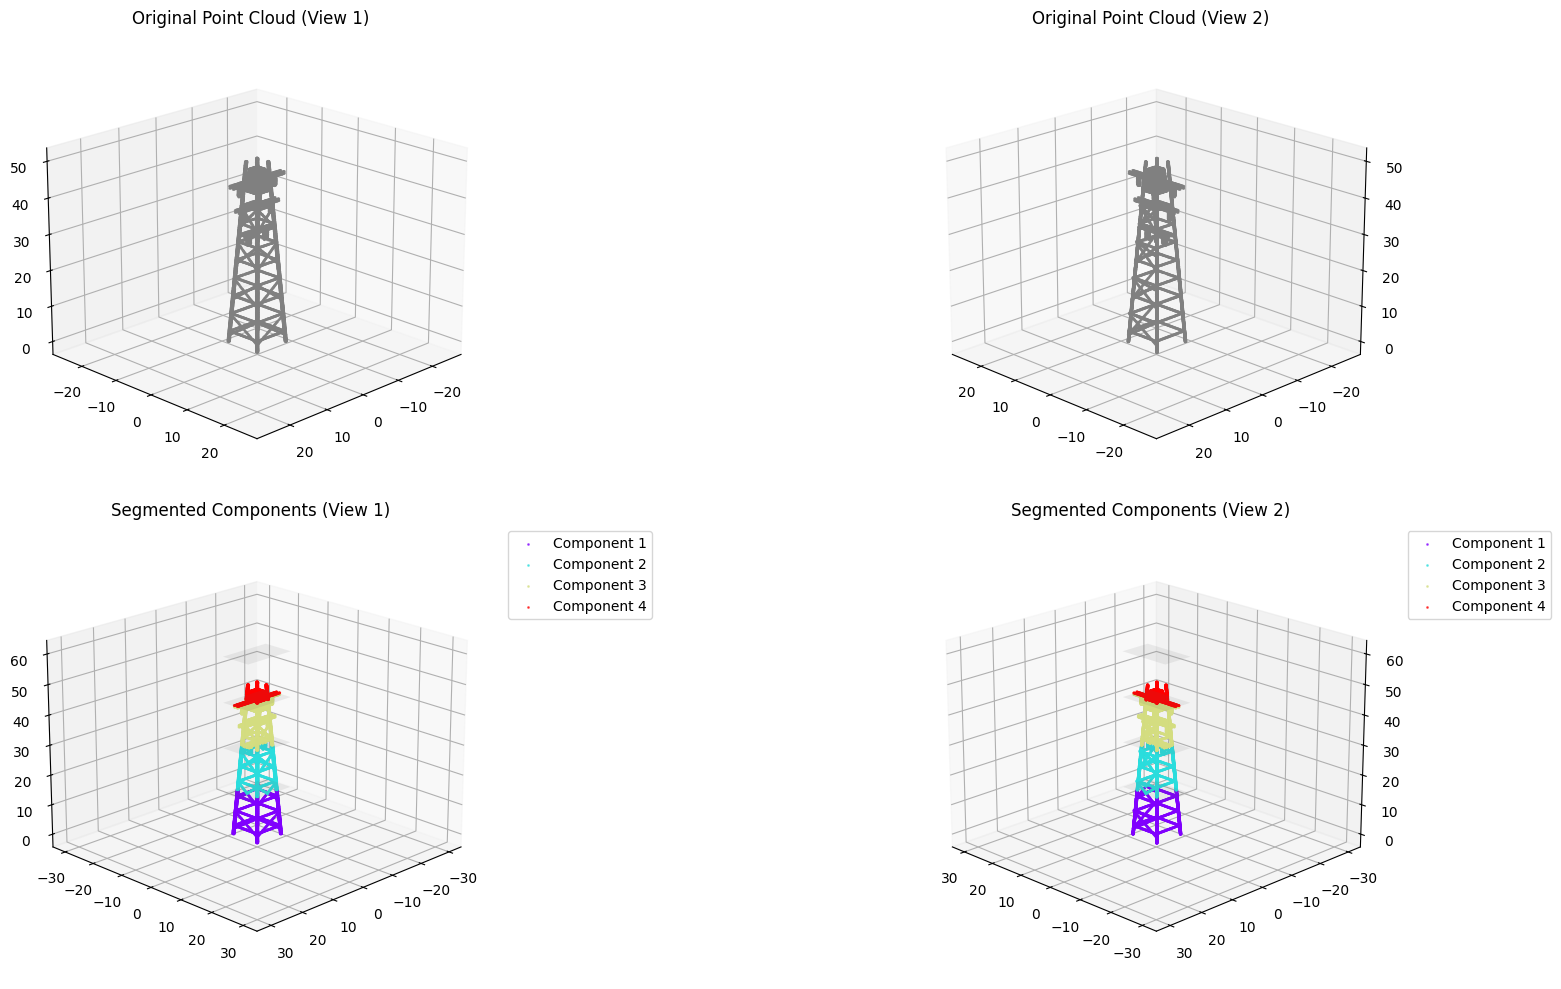


Component Statistics:
Component 1:
  Point Count: 5737
  Height Range: 0.00 m - 14.99 m
  Component Thickness: 14.99 m
Component 2:
  Point Count: 6153
  Height Range: 15.02 m - 30.00 m
  Component Thickness: 14.98 m
Component 3:
  Point Count: 13457
  Height Range: 30.00 m - 45.00 m
  Component Thickness: 15.00 m
Component 4:
  Point Count: 5876
  Height Range: 45.00 m - 49.95 m
  Component Thickness: 4.95 m


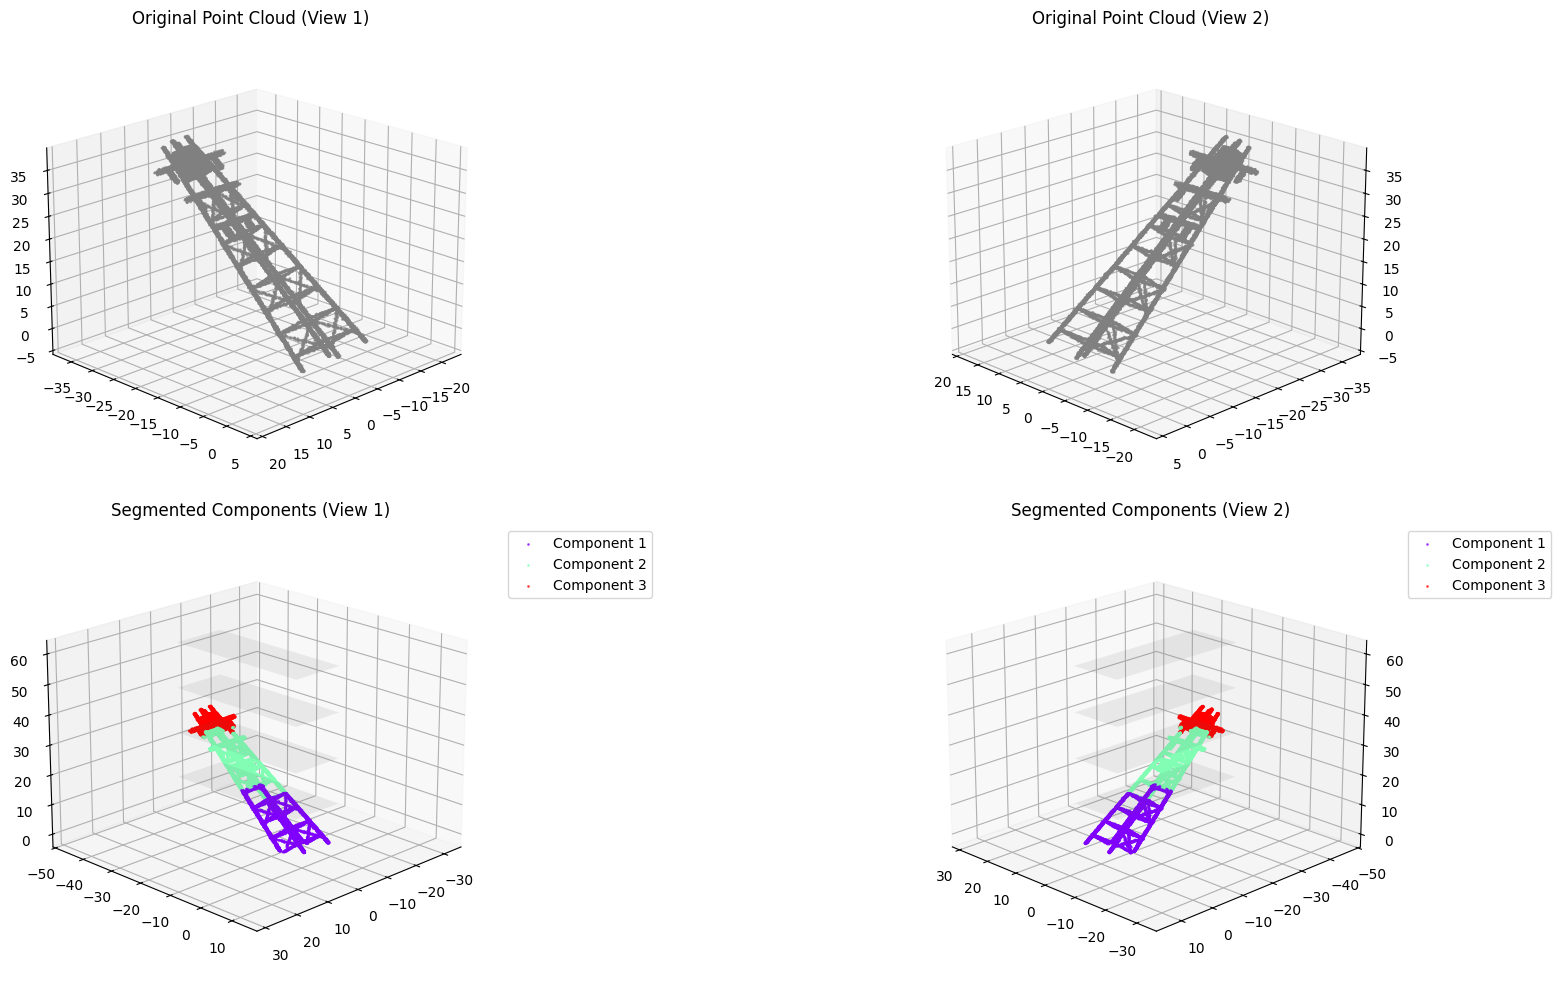

2025-07-14 06:46:38,921 - TowerRegistration - INFO - 开始电塔点云配准...
INFO:TowerRegistration:开始电塔点云配准...
2025-07-14 06:46:38,923 - TowerRegistration - INFO - 分割电塔构件...
INFO:TowerRegistration:分割电塔构件...
2025-07-14 06:46:38,929 - TowerRegistration - INFO - 执行构件级配准...
INFO:TowerRegistration:执行构件级配准...



Component Statistics:
Component 1:
  Point Count: 7243
  Height Range: 0.00 m - 15.00 m
  Component Thickness: 15.00 m
Component 2:
  Point Count: 11268
  Height Range: 15.00 m - 30.00 m
  Component Thickness: 15.00 m
Component 3:
  Point Count: 12024
  Height Range: 30.00 m - 36.93 m
  Component Thickness: 6.93 m

2. 执行常规配准...


2025-07-14 06:46:50,046 - TowerRegistration - INFO - 优化整体配准...
INFO:TowerRegistration:优化整体配准...
2025-07-14 06:46:53,320 - TowerRegistration - INFO - 评估配准结果...
INFO:TowerRegistration:评估配准结果...
2025-07-14 06:46:53,483 - TowerRegistration - INFO - 配准评估指标:
INFO:TowerRegistration:配准评估指标:
2025-07-14 06:46:53,485 - TowerRegistration - INFO - mean_distance: 0.651112
INFO:TowerRegistration:mean_distance: 0.651112
2025-07-14 06:46:53,487 - TowerRegistration - INFO - max_distance: 4.735911
INFO:TowerRegistration:max_distance: 4.735911
2025-07-14 06:46:53,489 - TowerRegistration - INFO - rmse: 1.062610
INFO:TowerRegistration:rmse: 1.062610
2025-07-14 06:46:53,491 - TowerRegistration - INFO - std_deviation: 0.839758
INFO:TowerRegistration:std_deviation: 0.839758
2025-07-14 06:46:53,493 - TowerRegistration - INFO - inlier_ratio: 0.680977
INFO:TowerRegistration:inlier_ratio: 0.680977
2025-07-14 06:46:53,494 - TowerRegistration - INFO - 开始IMU辅助的电塔点云配准...
INFO:TowerRegistration:开始IMU辅助的电塔点云配准...



3. 执行IMU辅助配准...


2025-07-14 06:46:57,839 - TowerRegistration - INFO - 配准评估指标:
INFO:TowerRegistration:配准评估指标:
2025-07-14 06:46:57,845 - TowerRegistration - INFO - mean_distance: 0.075421
INFO:TowerRegistration:mean_distance: 0.075421
2025-07-14 06:46:57,850 - TowerRegistration - INFO - max_distance: 0.258234
INFO:TowerRegistration:max_distance: 0.258234
2025-07-14 06:46:57,853 - TowerRegistration - INFO - rmse: 0.081949
INFO:TowerRegistration:rmse: 0.081949
2025-07-14 06:46:57,857 - TowerRegistration - INFO - std_deviation: 0.032051
INFO:TowerRegistration:std_deviation: 0.032051
2025-07-14 06:46:57,860 - TowerRegistration - INFO - inlier_ratio: 1.000000
INFO:TowerRegistration:inlier_ratio: 1.000000
/tmp/ipython-input-17-2750435594.py:693: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-17-2750435594.py:693: UserWarning: Glyph 22987 (\N{CJK UNIFIED IDEOGRAPH-59CB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/t


4. 显示配准过程...


/tmp/ipython-input-17-2750435594.py:693: UserWarning: Glyph 21021 (\N{CJK UNIFIED IDEOGRAPH-521D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-17-2750435594.py:693: UserWarning: Glyph 23545 (\N{CJK UNIFIED IDEOGRAPH-5BF9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-17-2750435594.py:693: UserWarning: Glyph 40784 (\N{CJK UNIFIED IDEOGRAPH-9F50}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-17-2750435594.py:693: UserWarning: Glyph 26368 (\N{CJK UNIFIED IDEOGRAPH-6700}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-17-2750435594.py:693: UserWarning: Glyph 32456 (\N{CJK UNIFIED IDEOGRAPH-7EC8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-17-2750435594.py:693: UserWarning: Glyph 32467 (\N{CJK UNIFIED IDEOGRAPH-7ED3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-17-2750435594.py:693: UserWarning: Glyph 26524 (\N{CJK UN

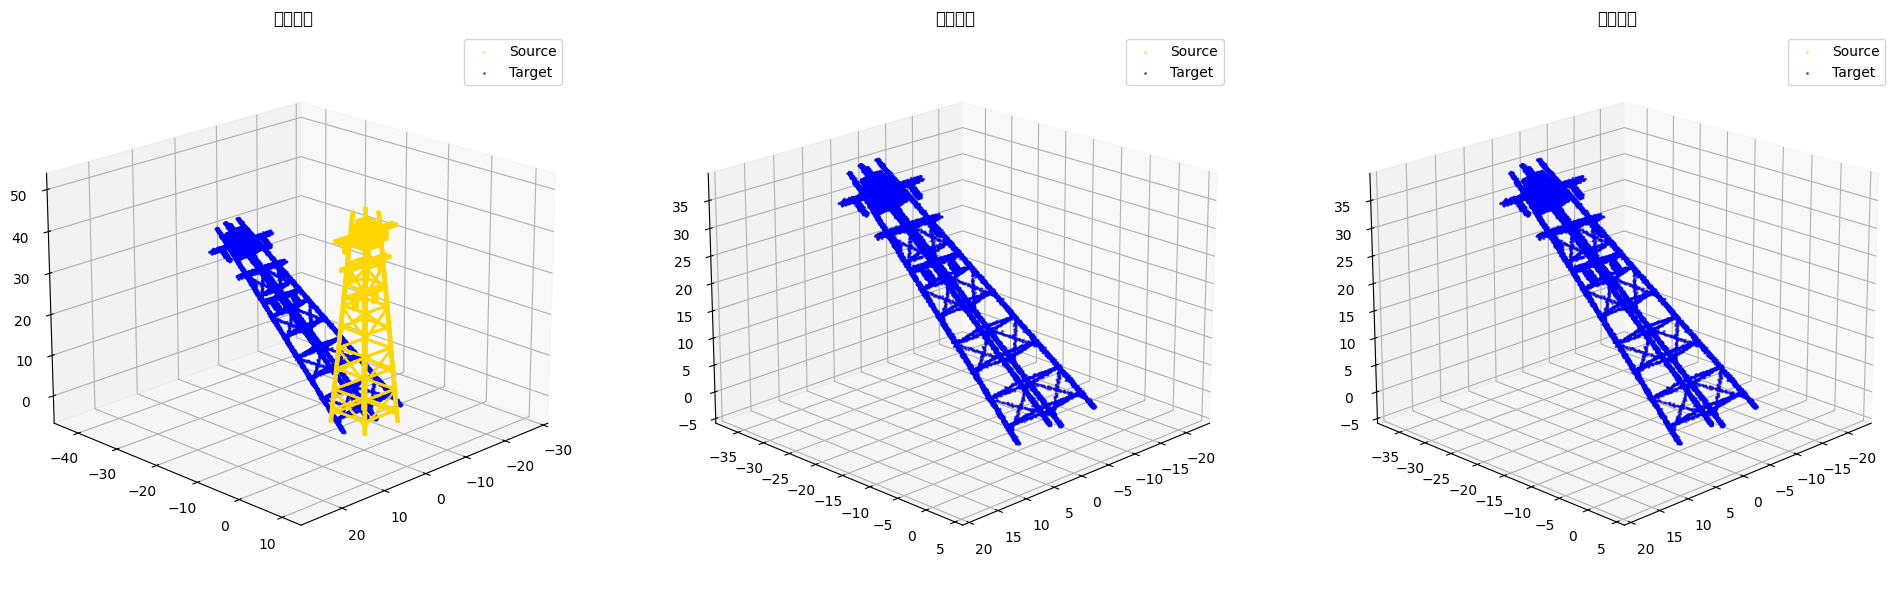


5. 显示构件级配准结果...


/tmp/ipython-input-17-2750435594.py:638: UserWarning: Glyph 26500 (\N{CJK UNIFIED IDEOGRAPH-6784}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-17-2750435594.py:638: UserWarning: Glyph 20214 (\N{CJK UNIFIED IDEOGRAPH-4EF6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-17-2750435594.py:638: UserWarning: Glyph 37197 (\N{CJK UNIFIED IDEOGRAPH-914D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-17-2750435594.py:638: UserWarning: Glyph 20934 (\N{CJK UNIFIED IDEOGRAPH-51C6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-17-2750435594.py:638: UserWarning: Glyph 32467 (\N{CJK UNIFIED IDEOGRAPH-7ED3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-17-2750435594.py:638: UserWarning: Glyph 26524 (\N{CJK UNIFIED IDEOGRAPH-679C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: User

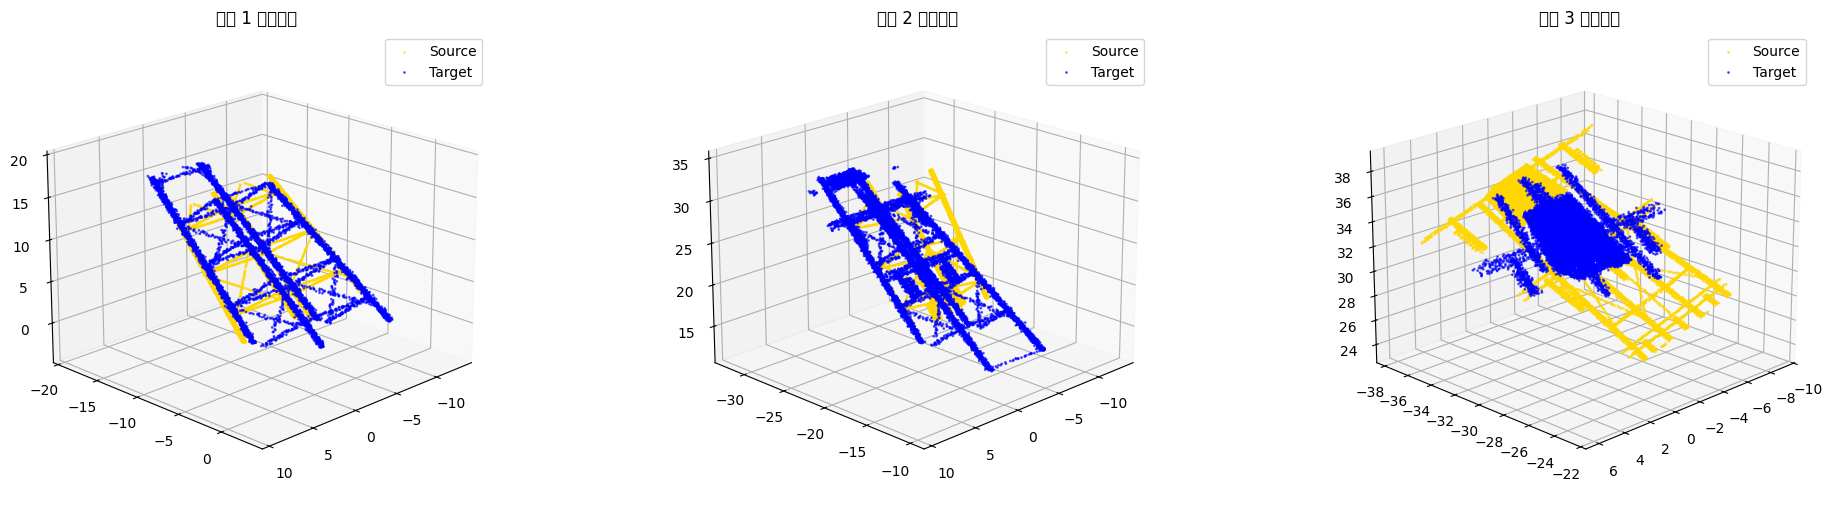


6. 显示配准对比结果...


/tmp/ipython-input-17-2750435594.py:808: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


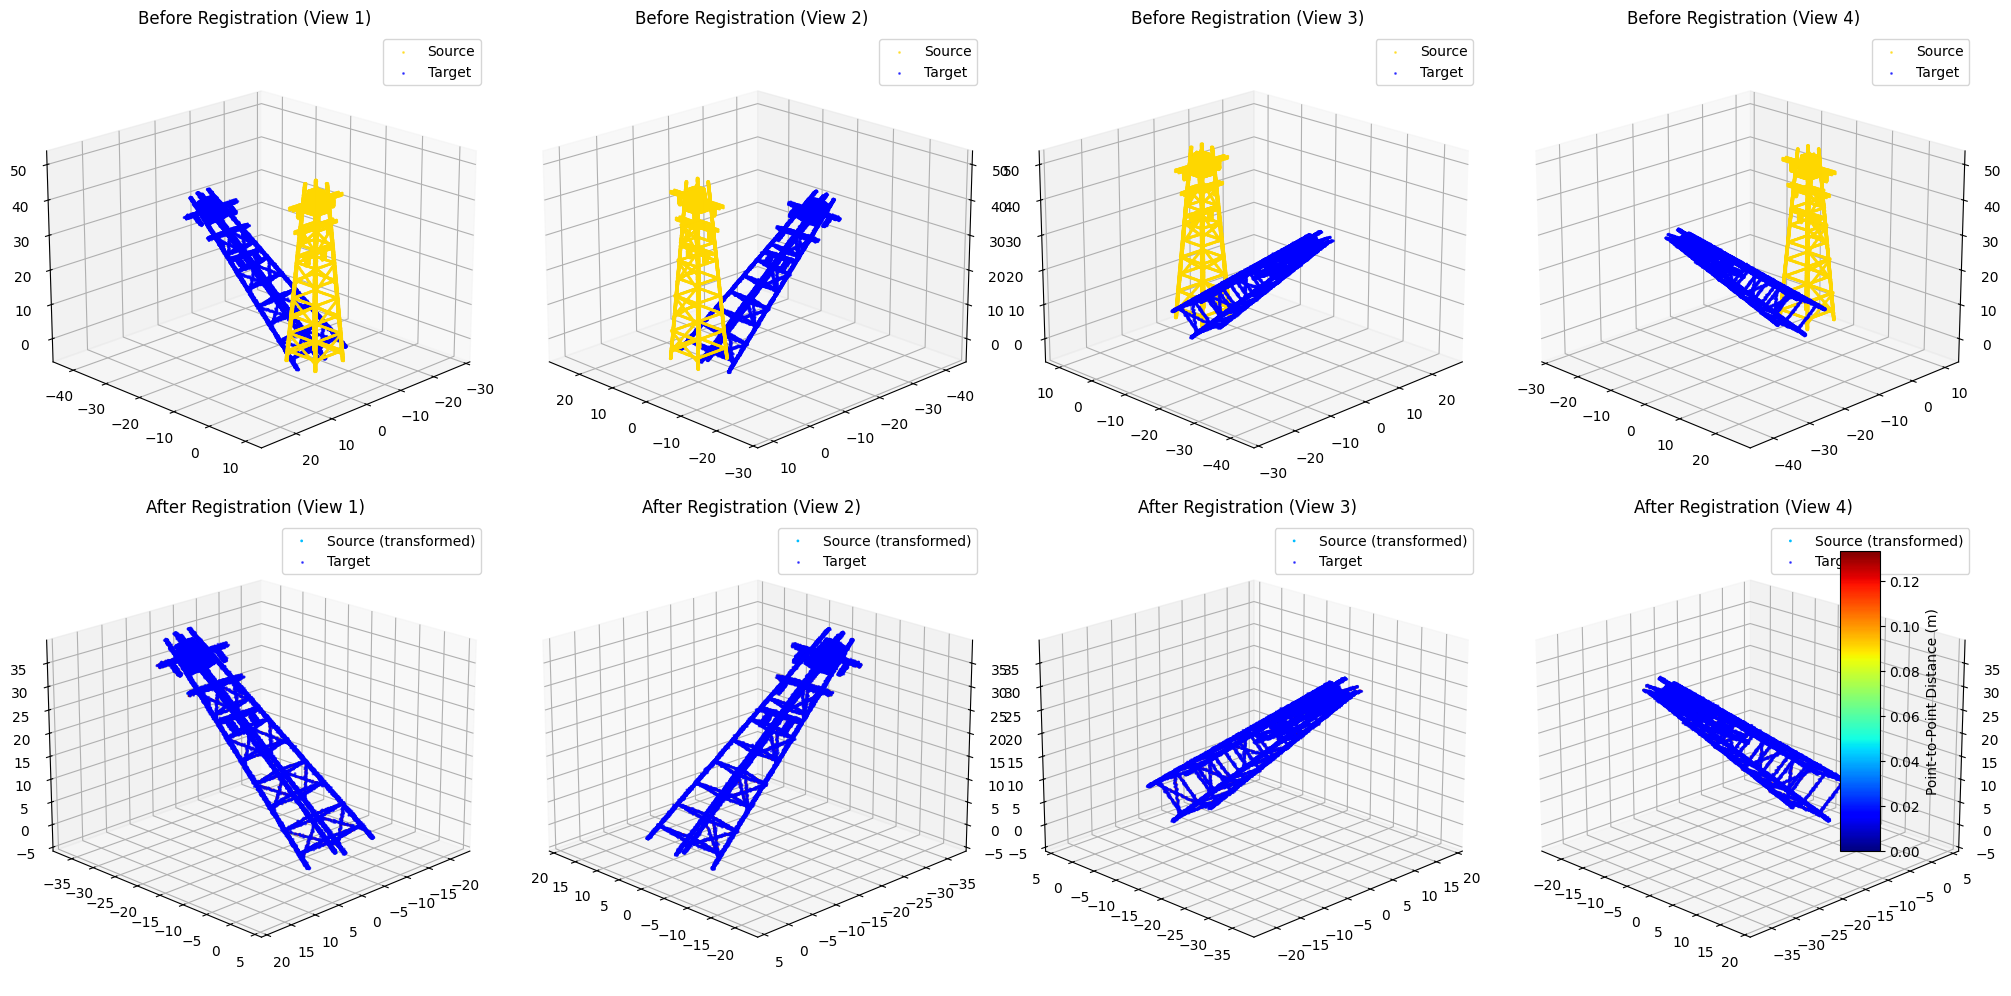


Registration Effect Statistics:
Average Point-to-Point Distance: 0.0754 m
Maximum Point-to-Point Distance: 0.2582 m
Distance Standard Deviation: 0.0321 m
Median Distance: 0.0722 m
95% Percentile Distance: 0.1333 m

7. 显示评估指标...


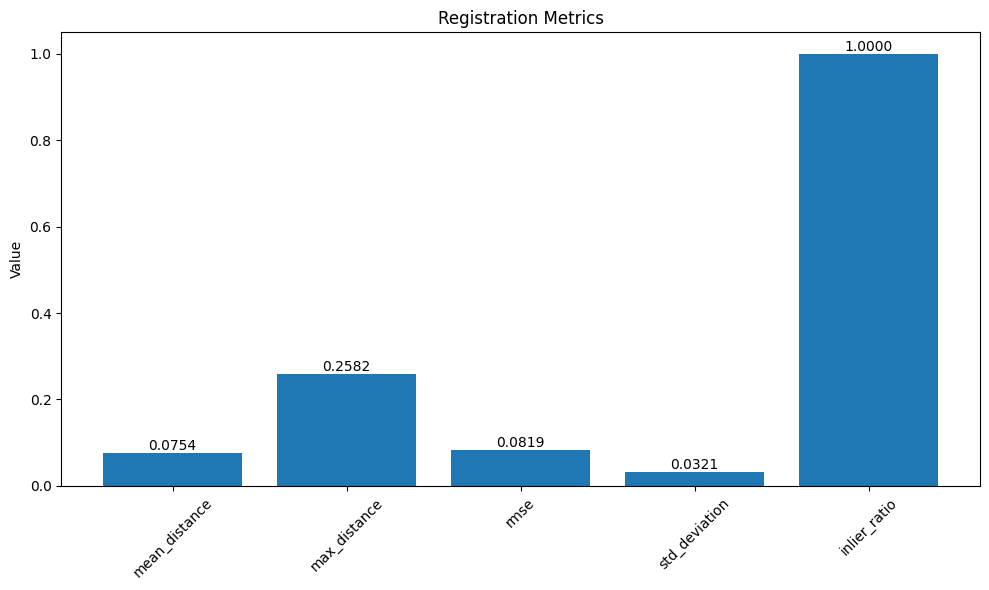


8. 显示IMU数据和轨迹...


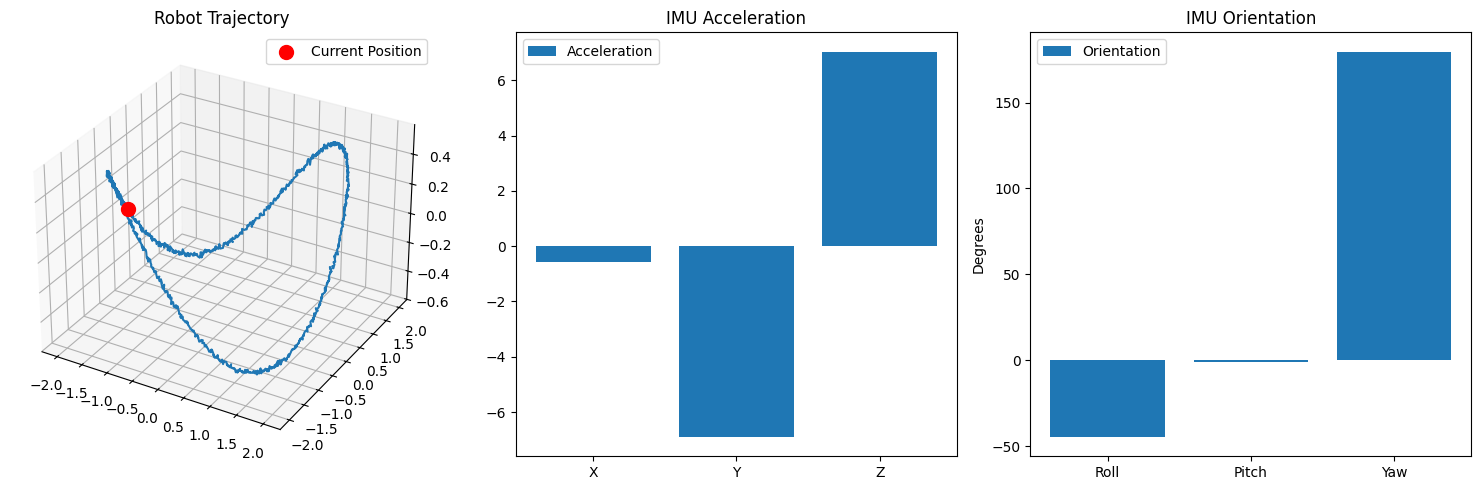


9. 显示综合可视化结果...


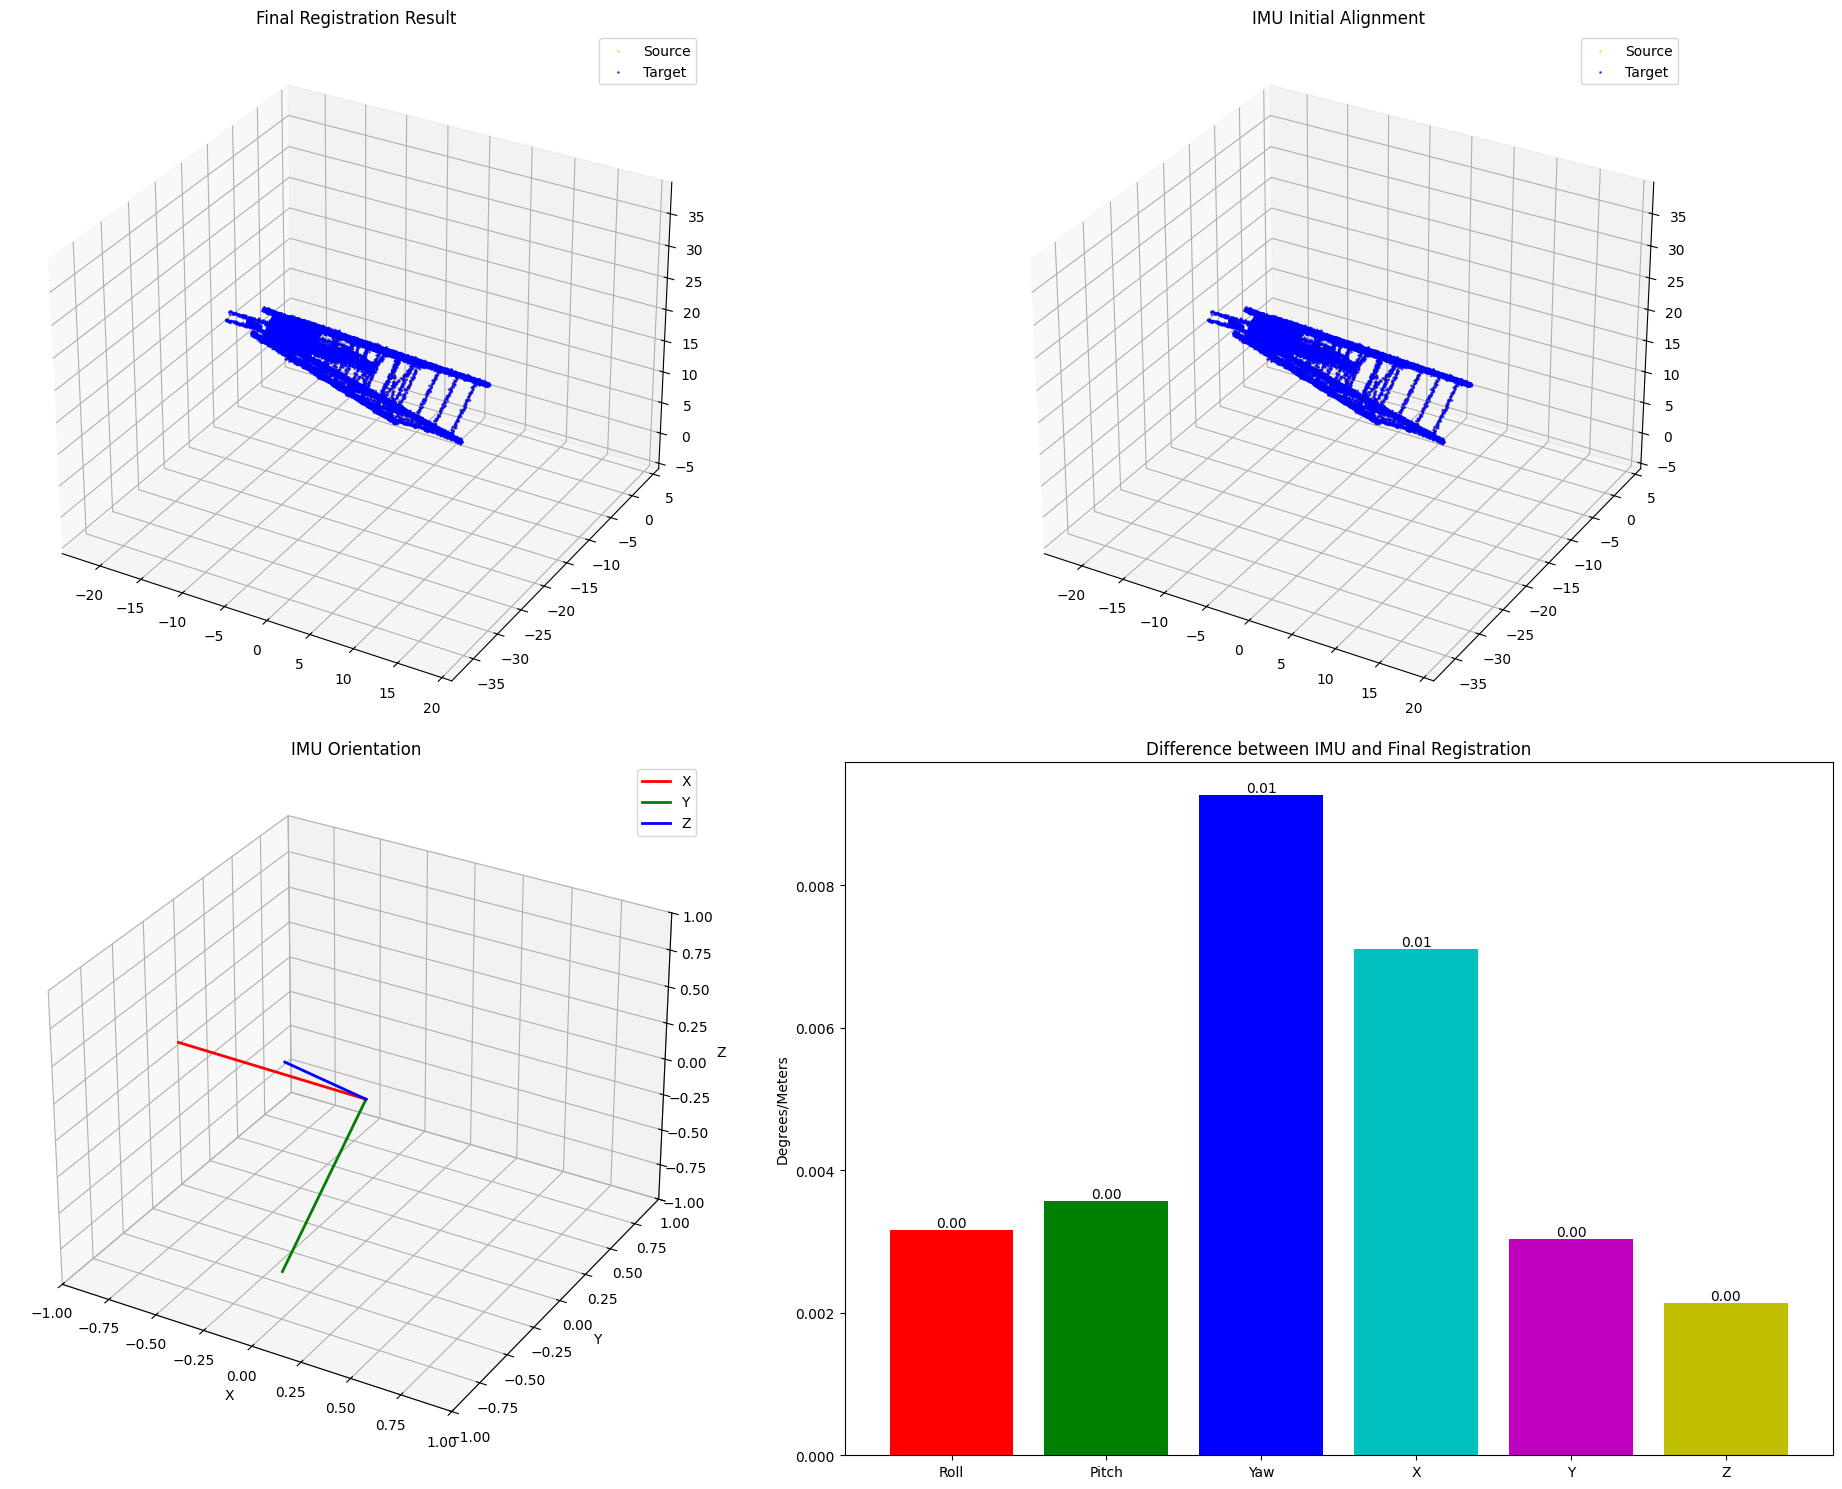

In [ ]:
import numpy as np
import open3d as o3d
from typing import Tuple, List, Dict, Optional
import copy
from sklearn.neighbors import KDTree
import logging
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.spatial.transform import Rotation
from scipy.interpolate import interp1d
import os

class RobotTrajectory:
    """机器人轨迹和IMU数据模拟类"""

    def __init__(self, duration: float = 10.0, sample_rate: float = 100.0):
        """
        初始化机器人轨迹模拟器

        Args:
            duration: 轨迹持续时间（秒）
            sample_rate: IMU采样率（Hz）
        """
        self.duration = duration
        self.sample_rate = sample_rate
        self.time_steps = np.arange(0, duration, 1/sample_rate)

        # 初始化轨迹数据
        self.positions = None
        self.orientations = None
        self.linear_velocities = None
        self.angular_velocities = None
        self.accelerations = None

    def generate_trajectory(self):
        """生成示例轨迹（可以根据实际需求修改）"""
        # 生成位置轨迹（示例：圆形轨迹）
        radius = 2.0
        omega = 2 * np.pi / self.duration  # 角速度

        # 位置轨迹
        self.positions = np.zeros((len(self.time_steps), 3))
        self.positions[:, 0] = radius * np.cos(omega * self.time_steps)
        self.positions[:, 1] = radius * np.sin(omega * self.time_steps)
        self.positions[:, 2] = 0.5 * np.sin(2 * omega * self.time_steps)  # 上下运动

        # 姿态轨迹（四元数）
        self.orientations = np.zeros((len(self.time_steps), 4))
        for i, t in enumerate(self.time_steps):
            # 根据运动方向计算姿态
            direction = np.array([-np.sin(omega * t), np.cos(omega * t), np.cos(2 * omega * t)])
            direction = direction / np.linalg.norm(direction)

            # 创建旋转矩阵（使机器人朝向运动方向）
            z_axis = direction
            x_axis = np.array([direction[1], -direction[0], 0])
            x_axis = x_axis / np.linalg.norm(x_axis)
            y_axis = np.cross(z_axis, x_axis)

            rotation_matrix = np.column_stack((x_axis, y_axis, z_axis))
            r = Rotation.from_matrix(rotation_matrix)
            self.orientations[i] = r.as_quat()

        # 计算速度和加速度
        dt = 1/self.sample_rate
        self.linear_velocities = np.gradient(self.positions, dt, axis=0)
        self.angular_velocities = np.zeros_like(self.positions)
        for i in range(len(self.time_steps)-1):
            q1 = self.orientations[i]
            q2 = self.orientations[i+1]
            # 计算角速度（简化版本）
            delta_q = Rotation.from_quat(q2) * Rotation.from_quat(q1).inv()
            angle = 2 * np.arccos(np.clip(delta_q.as_quat()[3], -1, 1))
            axis = delta_q.as_rotvec()
            if np.linalg.norm(axis) > 0:
                axis = axis / np.linalg.norm(axis)
            self.angular_velocities[i] = (angle / dt) * axis

        self.accelerations = np.gradient(self.linear_velocities, dt, axis=0)

        # 添加噪声
        self._add_noise()

    def _add_noise(self, pos_noise: float = 0.01,
                  orient_noise: float = 0.01,
                  accel_noise: float = 0.1,
                  gyro_noise: float = 0.01):
        """添加传感器噪声"""
        # 位置噪声
        self.positions += np.random.normal(0, pos_noise, self.positions.shape)

        # 姿态噪声
        orient_noise_euler = np.random.normal(0, orient_noise, (len(self.time_steps), 3))
        for i in range(len(self.time_steps)):
            noise_rotation = Rotation.from_euler('xyz', orient_noise_euler[i])
            current_rotation = Rotation.from_quat(self.orientations[i])
            noisy_rotation = noise_rotation * current_rotation
            self.orientations[i] = noisy_rotation.as_quat()

        # 加速度噪声
        self.accelerations += np.random.normal(0, accel_noise, self.accelerations.shape)

        # 角速度噪声
        self.angular_velocities += np.random.normal(0, gyro_noise, self.angular_velocities.shape)

    def _slerp(self, q1: np.ndarray, q2: np.ndarray, t: float) -> np.ndarray:
        """
        实现四元数球面线性插值（SLERP）

        Args:
            q1: 起始四元数
            q2: 结束四元数
            t: 插值参数 [0, 1]

        Returns:
            插值后的四元数
        """
        # 确保四元数是单位四元数
        q1 = q1 / np.linalg.norm(q1)
        q2 = q2 / np.linalg.norm(q2)

        # 计算四元数的点积
        dot = np.sum(q1 * q2)

        # 如果点积为负，取q2的相反数，这样可以保证走最短路径
        if dot < 0.0:
            q2 = -q2
            dot = -dot

        # 如果四元数非常接近，使用线性插值
        if dot > 0.9995:
            result = q1 + t * (q2 - q1)
            return result / np.linalg.norm(result)

        # 计算插值角度
        theta_0 = np.arccos(dot)
        sin_theta_0 = np.sin(theta_0)

        # 计算插值系数
        theta = theta_0 * t
        sin_theta = np.sin(theta)
        s0 = np.cos(theta) - dot * sin_theta / sin_theta_0
        s1 = sin_theta / sin_theta_0

        # 返回插值结果
        return (s0 * q1) + (s1 * q2)

    def get_pose_at_time(self, t: float) -> Tuple[np.ndarray, np.ndarray]:
        """获取指定时间的位姿"""
        if t < 0 or t > self.duration:
            raise ValueError(f"时间 {t} 超出轨迹范围 [0, {self.duration}]")

        # 使用插值获取位置
        pos_interp = interp1d(self.time_steps, self.positions, axis=0)
        position = pos_interp(t)

        # 对四元数进行球面线性插值
        idx = np.searchsorted(self.time_steps, t)
        if idx == 0:
            orientation = self.orientations[0]
        elif idx == len(self.time_steps):
            orientation = self.orientations[-1]
        else:
            t0, t1 = self.time_steps[idx-1], self.time_steps[idx]
            q0 = self.orientations[idx-1]
            q1 = self.orientations[idx]
            fraction = (t - t0) / (t1 - t0)
            orientation = self._slerp(q0, q1, fraction)

        return position, orientation

    def get_imu_data_at_time(self, t: float) -> Dict[str, np.ndarray]:
        """获取指定时间的IMU数据"""
        if t < 0 or t > self.duration:
            raise ValueError(f"时间 {t} 超出轨迹范围 [0, {self.duration}]")

        # 使用插值获取加速度和角速度
        accel_interp = interp1d(self.time_steps, self.accelerations, axis=0)
        gyro_interp = interp1d(self.time_steps, self.angular_velocities, axis=0)

        acceleration = accel_interp(t)
        angular_velocity = gyro_interp(t)

        # 获取姿态
        _, orientation = self.get_pose_at_time(t)
        rotation = Rotation.from_quat(orientation)

        # 将加速度转换到IMU坐标系
        acceleration_imu = rotation.inv().apply(acceleration + np.array([0, 0, 9.81]))
        angular_velocity_imu = rotation.inv().apply(angular_velocity)

        return {
            'acceleration': acceleration_imu,
            'angular_velocity': angular_velocity_imu,
            'orientation': rotation.as_euler('xyz')
        }

class TowerRegistration:
    """电塔点云配准类 - 实现构件级刚性配准"""

    def __init__(self, voxel_size: float = 0.5):
        """
        初始化配准参数

        Args:
            voxel_size: 体素降采样的大小（米）
        """
        self.voxel_size = voxel_size
        self.logger = self._setup_logger()
        self.robot_trajectory = None
        self.current_time = 0.0
        self._imu_data = {
            'roll': 0.0,
            'pitch': 0.0,
            'yaw': 0.0,
            'acceleration': np.array([0.0, 0.0, -9.81])  # 默认重力加速度
        }

    def _setup_logger(self) -> logging.Logger:
        """设置日志记录器"""
        logger = logging.getLogger('TowerRegistration')
        logger.setLevel(logging.INFO)
        if not logger.handlers:
            handler = logging.StreamHandler()
            formatter = logging.Formatter(
                '%(asctime)s - %(name)s - %(levelname)s - %(message)s'
            )
            handler.setFormatter(formatter)
            logger.addHandler(handler)
        return logger

    def _save_figure(self, save_path: str = None):
        """
        保存当前图形到文件

        Args:
            save_path: 保存路径，如果为None则不保存
        """
        if save_path:
            # 确保保存路径的目录存在
            save_dir = os.path.dirname(save_path)
            if save_dir and not os.path.exists(save_dir):
                os.makedirs(save_dir)
            plt.savefig(save_path, bbox_inches='tight', dpi=300)
            self.logger.info(f"图片已保存至: {save_path}")

    def preprocess_point_cloud(self, pcd: o3d.geometry.PointCloud,
                            coarse_voxel_size: float = None) -> Tuple[o3d.geometry.PointCloud,
                                                                     o3d.pipelines.registration.Feature]:
        """
        预处理点云数据：降采样、法向量估计、FPFH特征计算

        Args:
            pcd: 输入点云
            coarse_voxel_size: 粗配准时使用的体素大小，如果为None则使用默认体素大小

        Returns:
            降采样后的点云和FPFH特征
        """
        # 使用更大的体素尺寸进行粗配准
        current_voxel_size = coarse_voxel_size if coarse_voxel_size is not None else self.voxel_size

        # 体素降采样
        pcd_down = pcd.voxel_down_sample(current_voxel_size)

        # 估计法向量
        radius_normal = current_voxel_size * 2
        pcd_down.estimate_normals(
            o3d.geometry.KDTreeSearchParamHybrid(radius=radius_normal, max_nn=30))

        # 计算FPFH特征
        radius_feature = current_voxel_size * 5
        fpfh = o3d.pipelines.registration.compute_fpfh_feature(
            pcd_down,
            o3d.geometry.KDTreeSearchParamHybrid(radius=radius_feature, max_nn=100))

        # 特征点筛选 - 选择方差最大的特征点
        fpfh_features = np.asarray(fpfh.data).T
        feature_variance = np.var(fpfh_features, axis=1)
        top_indices = np.argsort(feature_variance)[-int(len(feature_variance) * 0.8):]  # 保留80%最显著的特征点

        # 更新点云和特征
        pcd_down_selected = o3d.geometry.PointCloud()
        pcd_down_selected.points = o3d.utility.Vector3dVector(np.asarray(pcd_down.points)[top_indices])
        pcd_down_selected.normals = o3d.utility.Vector3dVector(np.asarray(pcd_down.normals)[top_indices])

        fpfh_selected = o3d.pipelines.registration.Feature()
        fpfh_selected.data = fpfh.data[:, top_indices]

        return pcd_down_selected, fpfh_selected

    def segment_tower_components(self, pcd: o3d.geometry.PointCloud,
                               height_thresholds: List[float]) -> List[o3d.geometry.PointCloud]:
        """
        基于高度分割电塔构件

        Args:
            pcd: 输入点云
            height_thresholds: 高度阈值列表，用于分割不同构件

        Returns:
            分割后的构件点云列表
        """
        points = np.asarray(pcd.points)
        components = []

        # 按高度分割
        height_ranges = list(zip([0] + height_thresholds[:-1], height_thresholds))
        for h_min, h_max in height_ranges:
            mask = (points[:, 2] >= h_min) & (points[:, 2] < h_max)
            component = o3d.geometry.PointCloud()
            component.points = o3d.utility.Vector3dVector(points[mask])
            if len(component.points) > 0:
                components.append(component)

        return components

    def register_components(self, source_components: List[o3d.geometry.PointCloud],
                          target_components: List[o3d.geometry.PointCloud]) -> List[np.ndarray]:
        """
        对应构件之间的配准

        Args:
            source_components: 源点云构件列表
            target_components: 目标点云构件列表

        Returns:
            每个构件的变换矩阵列表
        """
        transformations = []

        for src_comp, tgt_comp in zip(source_components, target_components):
            # 预处理
            src_down, src_fpfh = self.preprocess_point_cloud(src_comp)
            tgt_down, tgt_fpfh = self.preprocess_point_cloud(tgt_comp)

            # RANSAC配准
            result = self.execute_global_registration(
                src_down, tgt_down, src_fpfh, tgt_fpfh
            )

            # ICP精配准
            refined_result = self.refine_registration(
                src_comp, tgt_comp, result.transformation
            )

            transformations.append(refined_result.transformation)

        return transformations

    def execute_global_registration(self, source_down: o3d.geometry.PointCloud,
                                  target_down: o3d.geometry.PointCloud,
                                  source_fpfh: o3d.pipelines.registration.Feature,
                                  target_fpfh: o3d.pipelines.registration.Feature,
                                  distance_threshold: float = 1.5,
                                  initial_transform: np.ndarray = None) -> o3d.pipelines.registration.RegistrationResult:
        """
        执行全局配准（改进的RANSAC）

        Args:
            source_down: 降采样后的源点云
            target_down: 降采样后的目标点云
            source_fpfh: 源点云FPFH特征
            target_fpfh: 目标点云FPFH特征
            distance_threshold: RANSAC距离阈值
            initial_transform: 初始变换矩阵（来自IMU等）

        Returns:
            配准结果
        """
        # 如果有初始变换，先进行预对齐
        if initial_transform is not None:
            source_down_transformed = copy.deepcopy(source_down)
            source_down_transformed.transform(initial_transform)
            # 减小搜索范围
            distance_threshold *= 0.5
        else:
            source_down_transformed = source_down

        # 使用更高效的RANSAC参数
        result = o3d.pipelines.registration.registration_ransac_based_on_feature_matching(
            source_down_transformed, target_down, source_fpfh, target_fpfh,
            mutual_filter=True,
            max_correspondence_distance=distance_threshold,
            estimation_method=o3d.pipelines.registration.TransformationEstimationPointToPoint(),
            ransac_n=4,
            checkers=[
                o3d.pipelines.registration.CorrespondenceCheckerBasedOnEdgeLength(0.9),
                o3d.pipelines.registration.CorrespondenceCheckerBasedOnDistance(distance_threshold)
            ],
            criteria=o3d.pipelines.registration.RANSACConvergenceCriteria(1000000, 1000)  # 减少迭代次数但增加采样点数
        )

        # 如果使用了初始变换，需要将结果与初始变换组合
        if initial_transform is not None:
            result.transformation = np.dot(result.transformation, initial_transform)

        return result

    def refine_registration(self, source: o3d.geometry.PointCloud,
                          target: o3d.geometry.PointCloud,
                          initial_transform: np.ndarray,
                          distance_threshold: float = 0.05) -> o3d.pipelines.registration.RegistrationResult:
        """
        使用ICP进行精配准

        Args:
            source: 源点云
            target: 目标点云
            initial_transform: 初始变换矩阵
            distance_threshold: ICP距离阈值

        Returns:
            精配准结果
        """
        result = o3d.pipelines.registration.registration_icp(
            source, target, distance_threshold, initial_transform,
            o3d.pipelines.registration.TransformationEstimationPointToPoint(),
            o3d.pipelines.registration.ICPConvergenceCriteria(max_iteration=100)
        )

        return result

    def evaluate_registration(self, source: o3d.geometry.PointCloud,
                            target: o3d.geometry.PointCloud,
                            transformation: np.ndarray) -> Dict:
        """
        评估配准结果

        Args:
            source: 源点云
            target: 目标点云
            transformation: 变换矩阵

        Returns:
            评估指标字典
        """
        # 转换源点云
        source_transformed = copy.deepcopy(source)
        source_transformed.transform(transformation)

        # 计算点到点距离
        source_points = np.asarray(source_transformed.points)
        target_points = np.asarray(target.points)

        # 使用KD树计算最近邻距离
        tree = KDTree(target_points)
        distances, _ = tree.query(source_points, k=1)
        distances = distances.flatten()

        # 计算评估指标
        metrics = {
            'mean_distance': np.mean(distances),
            'max_distance': np.max(distances),
            'rmse': np.sqrt(np.mean(distances ** 2)),
            'std_deviation': np.std(distances),
            'inlier_ratio': np.sum(distances < self.voxel_size) / len(distances)
        }

        return metrics

    def register_tower_clouds(self, source: o3d.geometry.PointCloud,
                            target: o3d.geometry.PointCloud,
                            height_thresholds: List[float] = None) -> Tuple[np.ndarray, Dict]:
        """
        执行完整的电塔点云配准流程

        Args:
            source: 源点云
            target: 目标点云
            height_thresholds: 构件分割的高度阈值

        Returns:
            最终变换矩阵和评估指标
        """
        if height_thresholds is None:
            # 默认高度阈值（根据电塔结构特点设置）
            height_thresholds = [15.0, 30.0, 45.0, 60.0]

        self.logger.info("开始电塔点云配准...")

        # 1. 分割构件
        self.logger.info("分割电塔构件...")
        source_components = self.segment_tower_components(source, height_thresholds)
        target_components = self.segment_tower_components(target, height_thresholds)

        # 2. 构件级配准
        self.logger.info("执行构件级配准...")
        component_transformations = self.register_components(
            source_components, target_components
        )

        # 3. 整体配准优化
        self.logger.info("优化整体配准...")
        # 使用最大构件的变换作为初始变换
        max_component_idx = np.argmax([len(comp.points) for comp in source_components])
        initial_transform = component_transformations[max_component_idx]

        # 对整体点云进行精配准
        final_result = self.refine_registration(
            source, target, initial_transform, distance_threshold=self.voxel_size
        )

        # 4. 评估配准结果
        self.logger.info("评估配准结果...")
        metrics = self.evaluate_registration(
            source, target, final_result.transformation
        )

        # 输出评估结果
        self.logger.info(f"配准评估指标:")
        for key, value in metrics.items():
            self.logger.info(f"{key}: {value:.6f}")

        return final_result.transformation, metrics

    def visualize_registration(self, source: o3d.geometry.PointCloud,
                             target: o3d.geometry.PointCloud,
                             transformation: np.ndarray = None,
                             window_size: Tuple[int, int] = (1000, 800),
                             save_path: str = None):
        """
        可视化点云配准结果

        Args:
            source: 源点云
            target: 目标点云
            transformation: 变换矩阵
            window_size: 窗口大小
            save_path: 保存图片的路径，如果为None则不保存
        """
        # 准备数据
        source_temp = copy.deepcopy(source)
        if transformation is not None:
            source_temp.transform(transformation)

        source_points = np.asarray(source_temp.points)
        target_points = np.asarray(target.points)

        # 创建3D图
        fig = plt.figure(figsize=(15, 12))
        ax = fig.add_subplot(111, projection='3d')

        # 绘制点云
        ax.scatter(source_points[:, 0], source_points[:, 1], source_points[:, 2],
                  c='gold', s=1, label='Source', alpha=0.6)
        ax.scatter(target_points[:, 0], target_points[:, 1], target_points[:, 2],
                  c='blue', s=1, label='Target', alpha=0.6)

        # 设置坐标轴标签
        ax.set_xlabel('X')
        ax.set_ylabel('Y')
        ax.set_zlabel('Z')

        # 设置标题和图例
        ax.set_title('点云配准结果可视化')
        ax.legend()

        # 设置相同的比例
        self._set_axes_equal(ax)

        # 优化视角
        ax.view_init(elev=20, azim=45)

        # 保存图片
        self._save_figure(save_path)
        plt.show()

    def _set_axes_equal(self, ax: plt.Axes):
        """
        使3D图的坐标轴比例相同

        Args:
            ax: matplotlib的3D坐标轴
        """
        limits = np.array([
            ax.get_xlim3d(),
            ax.get_ylim3d(),
            ax.get_zlim3d(),
        ])

        origin = np.mean(limits, axis=1)
        radius = 0.5 * np.max(np.abs(limits[:, 1] - limits[:, 0]))

        ax.set_xlim3d([origin[0] - radius, origin[0] + radius])
        ax.set_ylim3d([origin[1] - radius, origin[1] + radius])
        ax.set_zlim3d([origin[2] - radius, origin[2] + radius])

    def visualize_components(self, source_components: List[o3d.geometry.PointCloud],
                           target_components: List[o3d.geometry.PointCloud],
                           transformations: List[np.ndarray] = None,
                           window_size: Tuple[int, int] = (1200, 800),
                           save_path: str = None):
        """
        可视化构件级配准结果

        Args:
            source_components: 源点云构件列表
            target_components: 目标点云构件列表
            transformations: 变换矩阵列表
            window_size: 窗口大小
            save_path: 保存图片的路径，如果为None则不保存
        """
        n_components = len(source_components)
        n_cols = min(3, n_components)
        n_rows = (n_components + n_cols - 1) // n_cols

        fig = plt.figure(figsize=(20, 5*n_rows))

        for i, (source, target) in enumerate(zip(source_components, target_components)):
            # 准备数据
            source_temp = copy.deepcopy(source)
            if transformations is not None and i < len(transformations):
                source_temp.transform(transformations[i])

            source_points = np.asarray(source_temp.points)
            target_points = np.asarray(target.points)

            # 创建子图
            ax = fig.add_subplot(n_rows, n_cols, i+1, projection='3d')

            # 绘制点云
            ax.scatter(source_points[:, 0], source_points[:, 1], source_points[:, 2],
                      c='gold', s=1, label='Source', alpha=0.6)
            ax.scatter(target_points[:, 0], target_points[:, 1], target_points[:, 2],
                      c='blue', s=1, label='Target', alpha=0.6)

            # 设置标题和图例
            ax.set_title(f'构件 {i+1} 配准结果')
            ax.legend()

            # 设置相同的比例
            self._set_axes_equal(ax)

            # 优化视角
            ax.view_init(elev=20, azim=45)

        plt.tight_layout()

        # 保存图片
        self._save_figure(save_path)
        plt.show()

    def visualize_registration_process(self, source: o3d.geometry.PointCloud,
                                    target: o3d.geometry.PointCloud,
                                    initial_transform: np.ndarray = None,
                                    final_transform: np.ndarray = None,
                                    window_size: Tuple[int, int] = (1200, 400),
                                    save_path: str = None):
        """
        可视化配准过程

        Args:
            source: 源点云
            target: 目标点云
            initial_transform: 初始变换矩阵
            final_transform: 最终变换矩阵
            window_size: 窗口大小
            save_path: 保存图片的路径，如果为None则不保存
        """
        fig = plt.figure(figsize=(20, 6))
        titles = ['原始点云', '初始对齐', '最终结果']
        transforms = [None, initial_transform, final_transform]

        for i, (title, transform) in enumerate(zip(titles, transforms)):
            # 准备数据
            source_temp = copy.deepcopy(source)
            if transform is not None:
                source_temp.transform(transform)

            source_points = np.asarray(source_temp.points)
            target_points = np.asarray(target.points)

            # 创建子图
            ax = fig.add_subplot(1, 3, i+1, projection='3d')

            # 绘制点云
            ax.scatter(source_points[:, 0], source_points[:, 1], source_points[:, 2],
                      c='gold', s=1, label='Source', alpha=0.6)
            ax.scatter(target_points[:, 0], target_points[:, 1], target_points[:, 2],
                      c='blue', s=1, label='Target', alpha=0.6)

            # 设置标题和图例
            ax.set_title(title)
            ax.legend()

            # 设置相同的比例
            self._set_axes_equal(ax)

            # 优化视角
            ax.view_init(elev=20, azim=45)

        plt.tight_layout()

        # 保存图片
        self._save_figure(save_path)
        plt.show()

    def visualize_metrics(self, metrics: Dict, save_path: str = None):
        """
        可视化配准评估指标

        Args:
            metrics: 评估指标字典
            save_path: 保存图片的路径，如果为None则不保存
        """
        # 创建条形图
        plt.figure(figsize=(10, 6))

        # 提取数据
        metric_names = list(metrics.keys())
        metric_values = list(metrics.values())

        # 创建条形图
        bars = plt.bar(range(len(metrics)), metric_values)

        # 设置标签
        plt.xticks(range(len(metrics)), metric_names, rotation=45)
        plt.ylabel('Value')
        plt.title('Registration Metrics')

        # 在条形上添加具体数值
        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.4f}',
                    ha='center', va='bottom')

        plt.tight_layout()

        # 保存图片
        self._save_figure(save_path)
        plt.show()

    def visualize_registration_comparison(self, source: o3d.geometry.PointCloud,
                                       target: o3d.geometry.PointCloud,
                                       transformation: np.ndarray,
                                       view_angles: List[Tuple[float, float]] = None,
                                       save_path: str = None):
        """
        可视化配准前后的对比效果，从多个角度展示

        Args:
            source: 源点云
            target: 目标点云
            transformation: 变换矩阵
            view_angles: 视角列表，每个元素为(elevation, azimuth)元组
            save_path: 保存图片的路径，如果为None则不保存
        """
        if view_angles is None:
            view_angles = [(20, 45), (20, 135), (20, 225), (20, 315)]

        n_views = len(view_angles)
        fig = plt.figure(figsize=(20, 10))

        # 配准前
        source_points = np.asarray(source.points)
        target_points = np.asarray(target.points)

        # 配准后
        source_transformed = copy.deepcopy(source)
        source_transformed.transform(transformation)
        source_transformed_points = np.asarray(source_transformed.points)

        # 计算点云距离用于颜色映射
        tree = KDTree(target_points)
        distances, _ = tree.query(source_transformed_points, k=1)
        max_dist = np.percentile(distances, 95)  # 使用95百分位数作为最大距离，避免异常值影响

        # 创建颜色映射
        norm = plt.Normalize(0, max_dist)
        cmap = plt.cm.jet

        for i, (elev, azim) in enumerate(view_angles):
            # 配准前
            ax1 = fig.add_subplot(2, n_views, i+1, projection='3d')
            ax1.scatter(source_points[:, 0], source_points[:, 1], source_points[:, 2],
                      c='gold', s=1, label='Source', alpha=0.6)
            ax1.scatter(target_points[:, 0], target_points[:, 1], target_points[:, 2],
                      c='blue', s=1, label='Target', alpha=0.6)
            ax1.view_init(elev=elev, azim=azim)
            ax1.set_title(f'Before Registration (View {i+1})')
            self._set_axes_equal(ax1)
            ax1.legend()

            # 配准后
            ax2 = fig.add_subplot(2, n_views, i+n_views+1, projection='3d')
            scatter = ax2.scatter(source_transformed_points[:, 0],
                                source_transformed_points[:, 1],
                                source_transformed_points[:, 2],
                                c=distances.flatten(),
                                cmap=cmap,
                                norm=norm,
                                s=1,
                                label='Source (transformed)')
            ax2.scatter(target_points[:, 0], target_points[:, 1], target_points[:, 2],
                      c='blue', s=1, label='Target', alpha=0.6)
            ax2.view_init(elev=elev, azim=azim)
            ax2.set_title(f'After Registration (View {i+1})')
            self._set_axes_equal(ax2)
            ax2.legend()

        # 添加颜色条
        cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.3])
        cbar = fig.colorbar(scatter, cax=cbar_ax)
        cbar.set_label('Point-to-Point Distance (m)')

        plt.tight_layout()

        # 保存图片
        self._save_figure(save_path)
        plt.show()

        # 输出统计信息
        print("\nRegistration Effect Statistics:")
        print(f"Average Point-to-Point Distance: {np.mean(distances):.4f} m")
        print(f"Maximum Point-to-Point Distance: {np.max(distances):.4f} m")
        print(f"Distance Standard Deviation: {np.std(distances):.4f} m")
        print(f"Median Distance: {np.median(distances):.4f} m")
        print(f"95% Percentile Distance: {max_dist:.4f} m")

    def visualize_components_extraction(self, pcd: o3d.geometry.PointCloud,
                                     height_thresholds: List[float] = None,
                                     view_angles: List[Tuple[float, float]] = None,
                                     save_path: str = None):
        """
        可视化构件提取效果

        Args:
            pcd: 输入点云
            height_thresholds: 高度阈值列表
            view_angles: 视角列表，每个元素为(elevation, azimuth)元组
            save_path: 保存图片的路径，如果为None则不保存
        """
        if height_thresholds is None:
            height_thresholds = [15.0, 30.0, 45.0, 60.0]

        if view_angles is None:
            view_angles = [(20, 45), (20, 135)]

        # 分割构件
        components = self.segment_tower_components(pcd, height_thresholds)

        # 为每个构件分配不同的颜色
        colors = plt.cm.rainbow(np.linspace(0, 1, len(components)))

        # 创建图形
        fig = plt.figure(figsize=(20, 10))
        n_views = len(view_angles)

        # 绘制原始点云
        points = np.asarray(pcd.points)
        for i, (elev, azim) in enumerate(view_angles):
            ax = fig.add_subplot(2, n_views, i+1, projection='3d')
            ax.scatter(points[:, 0], points[:, 1], points[:, 2],
                      c='gray', s=1, alpha=0.6)
            ax.view_init(elev=elev, azim=azim)
            ax.set_title(f'Original Point Cloud (View {i+1})')
            self._set_axes_equal(ax)

        # 绘制分割后的构件
        for i, (elev, azim) in enumerate(view_angles):
            ax = fig.add_subplot(2, n_views, i+n_views+1, projection='3d')

            # 绘制每个构件
            for j, component in enumerate(components):
                comp_points = np.asarray(component.points)
                ax.scatter(comp_points[:, 0], comp_points[:, 1], comp_points[:, 2],
                          c=[colors[j]], s=1, label=f'Component {j+1}',
                          alpha=0.6)

            # 添加高度阈值平面
            x_min, x_max = points[:, 0].min(), points[:, 0].max()
            y_min, y_max = points[:, 1].min(), points[:, 1].max()
            for h in height_thresholds:
                xx, yy = np.meshgrid([x_min, x_max], [y_min, y_max])
                zz = np.full_like(xx, h)
                ax.plot_surface(xx, yy, zz, alpha=0.1, color='gray')

            ax.view_init(elev=elev, azim=azim)
            ax.set_title(f'Segmented Components (View {i+1})')
            self._set_axes_equal(ax)
            ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

        plt.tight_layout()

        # 保存图片
        self._save_figure(save_path)
        plt.show()

        # 输出构件统计信息
        print("\nComponent Statistics:")
        for i, component in enumerate(components):
            points = np.asarray(component.points)
            height_range = (points[:, 2].min(), points[:, 2].max())
            print(f"Component {i+1}:")
            print(f"  Point Count: {len(points)}")
            print(f"  Height Range: {height_range[0]:.2f} m - {height_range[1]:.2f} m")
            print(f"  Component Thickness: {height_range[1] - height_range[0]:.2f} m")

    def set_robot_trajectory(self, trajectory: RobotTrajectory):
        """
        设置机器人轨迹

        Args:
            trajectory: RobotTrajectory对象
        """
        self.robot_trajectory = trajectory
        self.logger.info("已设置机器人轨迹")

    def update_imu_data(self, time: float):
        """
        更新IMU数据

        Args:
            time: 当前时间点
        """
        if self.robot_trajectory is None:
            raise ValueError("未设置机器人轨迹")

        imu_data = self.robot_trajectory.get_imu_data_at_time(time)
        self._imu_data = {
            'roll': imu_data['orientation'][0],
            'pitch': imu_data['orientation'][1],
            'yaw': imu_data['orientation'][2],
            'acceleration': imu_data['acceleration']
        }
        self.current_time = time
        self.logger.info(f"已更新IMU数据，时间: {time:.2f}秒")

    def get_current_pose(self) -> Tuple[np.ndarray, np.ndarray]:
        """
        获取当前位姿

        Returns:
            位置和姿态四元数
        """
        if self.robot_trajectory is None:
            raise ValueError("未设置机器人轨迹")

        return self.robot_trajectory.get_pose_at_time(self.current_time)

    def set_imu_data(self, roll: float, pitch: float, yaw: float, acceleration: np.ndarray):
        """
        直接设置IMU数据

        Args:
            roll: 横滚角（弧度）
            pitch: 俯仰角（弧度）
            yaw: 偏航角（弧度）
            acceleration: 加速度向量 [ax, ay, az]
        """
        self._imu_data = {
            'roll': roll,
            'pitch': pitch,
            'yaw': yaw,
            'acceleration': acceleration
        }
        self.logger.info("已直接设置IMU数据")

    def get_initial_transform_from_imu(self) -> np.ndarray:
        """
        从IMU数据获取初始变换矩阵

        Returns:
            4x4变换矩阵
        """
        # 从欧拉角创建旋转矩阵
        euler_angles = [self._imu_data['roll'],
                       self._imu_data['pitch'],
                       self._imu_data['yaw']]
        rotation = Rotation.from_euler('xyz', euler_angles)
        rotation_matrix = rotation.as_matrix()

        # 使用加速度数据估计位移（简化版本）
        translation = np.zeros(3)
        if self.robot_trajectory is not None:
            position, _ = self.get_current_pose()
            translation = position

        # 构建4x4变换矩阵
        transform = np.eye(4)
        transform[:3, :3] = rotation_matrix
        transform[:3, 3] = translation

        return transform

    def register_with_imu(self, source: o3d.geometry.PointCloud,
                         target: o3d.geometry.PointCloud,
                         height_thresholds: List[float] = None) -> Tuple[np.ndarray, Dict]:
        """
        使用IMU辅助的点云配准

        Args:
            source: 源点云
            target: 目标点云
            height_thresholds: 构件分割的高度阈值

        Returns:
            最终变换矩阵和评估指标
        """
        if height_thresholds is None:
            height_thresholds = [15.0, 30.0, 45.0, 60.0]

        self.logger.info("开始IMU辅助的电塔点云配准...")

        # 获取IMU初始变换
        imu_transform = self.get_initial_transform_from_imu()

        # 使用更大的体素尺寸进行粗配准
        coarse_voxel_size = self.voxel_size * 2
        source_down, source_fpfh = self.preprocess_point_cloud(source, coarse_voxel_size)
        target_down, target_fpfh = self.preprocess_point_cloud(target, coarse_voxel_size)

        # 使用IMU变换进行RANSAC配准
        result = self.execute_global_registration(
            source_down, target_down,
            source_fpfh, target_fpfh,
            distance_threshold=coarse_voxel_size * 1.5,
            initial_transform=imu_transform
        )

        # 使用原始体素尺寸进行精配准
        source_down_fine, source_fpfh_fine = self.preprocess_point_cloud(source)
        target_down_fine, target_fpfh_fine = self.preprocess_point_cloud(target)

        # 多级ICP精配准
        current_transform = result.transformation
        distance_thresholds = [self.voxel_size * 2, self.voxel_size]

        for dist_threshold in distance_thresholds:
            refined_result = self.refine_registration(
                source_down_fine, target_down_fine,
                current_transform, distance_threshold=dist_threshold
            )
            current_transform = refined_result.transformation

        # 最终精配准
        final_result = self.refine_registration(
            source, target,
            current_transform,
            distance_threshold=self.voxel_size * 0.5
        )

        # 评估结果
        metrics = self.evaluate_registration(
            source, target, final_result.transformation
        )

        self.logger.info(f"配准评估指标:")
        for key, value in metrics.items():
            self.logger.info(f"{key}: {value:.6f}")

        return final_result.transformation, metrics

    def visualize_imu_data(self, save_path: str = None):
        """
        可视化IMU数据，包括姿态和加速度
        """
        if self._imu_data is None:
            print("没有IMU数据可供可视化")
            return

        # 创建2x2的子图布局
        fig = plt.figure(figsize=(15, 10))

        # 1. 欧拉角可视化
        ax1 = fig.add_subplot(221)
        euler_angles = [self._imu_data['roll'], self._imu_data['pitch'], self._imu_data['yaw']]
        ax1.bar(['Roll', 'Pitch', 'Yaw'], np.rad2deg(euler_angles))
        ax1.set_title('IMU Euler Angles')
        ax1.set_ylabel('Degrees')

        # 2. 加速度可视化
        ax2 = fig.add_subplot(222)
        accel = self._imu_data['acceleration']
        ax2.bar(['X', 'Y', 'Z'], accel)
        ax2.set_title('IMU Acceleration')
        ax2.set_ylabel('m/s²')

        # 3. 3D姿态可视化
        ax3 = fig.add_subplot(223, projection='3d')
        self._visualize_imu_orientation(ax3)
        ax3.set_title('IMU Orientation')

        # 4. 加速度向量可视化
        ax4 = fig.add_subplot(224, projection='3d')
        self._visualize_acceleration_vector(ax4)
        ax4.set_title('Acceleration Vector')

        plt.tight_layout()

        # 保存图片
        self._save_figure(save_path)
        plt.show()

    def _visualize_imu_orientation(self, ax: plt.Axes):
        """
        在3D坐标系中可视化IMU姿态
        """
        # 获取旋转矩阵
        r = Rotation.from_euler('xyz', [self._imu_data['roll'],
                                      self._imu_data['pitch'],
                                      self._imu_data['yaw']])
        rotation_matrix = r.as_matrix()

        # 绘制坐标轴
        origin = np.zeros(3)
        colors = ['r', 'g', 'b']
        labels = ['X', 'Y', 'Z']

        for i in range(3):
            axis = np.zeros((2, 3))
            axis[1] = rotation_matrix[:, i]  # 旋转后的坐标轴
            ax.plot(axis[:, 0], axis[:, 1], axis[:, 2],
                   color=colors[i], linewidth=2, label=labels[i])

        # 设置图形属性
        ax.set_xlabel('X')
        ax.set_ylabel('Y')
        ax.set_zlabel('Z')
        ax.set_xlim([-1, 1])
        ax.set_ylim([-1, 1])
        ax.set_zlim([-1, 1])
        ax.legend()

    def _visualize_acceleration_vector(self, ax: plt.Axes):
        """
        在3D坐标系中可视化加速度向量
        """
        # 归一化加速度向量
        accel = self._imu_data['acceleration']
        accel_norm = accel / np.linalg.norm(accel)

        # 绘制加速度向量
        origin = np.zeros(3)
        ax.quiver(origin[0], origin[1], origin[2],
                 accel_norm[0], accel_norm[1], accel_norm[2],
                 color='r', length=1, normalize=True, label='Acceleration')

        # 绘制参考坐标轴
        for i, (color, label) in enumerate(zip(['r', 'g', 'b'], ['X', 'Y', 'Z'])):
            axis = np.zeros((2, 3))
            axis[1, i] = 1
            ax.plot(axis[:, 0], axis[:, 1], axis[:, 2],
                   color=color, linestyle='--', alpha=0.3, label=f'{label} axis')

        # 设置图形属性
        ax.set_xlabel('X')
        ax.set_ylabel('Y')
        ax.set_zlabel('Z')
        ax.set_xlim([-1, 1])
        ax.set_ylim([-1, 1])
        ax.set_zlim([-1, 1])
        ax.legend()

    def visualize_registration_with_imu(self, source: o3d.geometry.PointCloud,
                                      target: o3d.geometry.PointCloud,
                                      imu_transform: np.ndarray,
                                      final_transform: np.ndarray,
                                      save_path: str = None):
        """
        综合可视化配准结果和IMU数据
        """
        # 创建2x2的布局
        fig = plt.figure(figsize=(20, 15))

        # 1. 点云配准结果
        ax1 = fig.add_subplot(221, projection='3d')
        self._plot_registration_result(ax1, source, target, final_transform, 'Final Registration Result')

        # 2. IMU初始对齐
        ax2 = fig.add_subplot(222, projection='3d')
        self._plot_registration_result(ax2, source, target, imu_transform, 'IMU Initial Alignment')

        # 3. IMU姿态
        ax3 = fig.add_subplot(223, projection='3d')
        self._visualize_imu_orientation(ax3)
        ax3.set_title('IMU Orientation')

        # 4. 误差分析
        ax4 = fig.add_subplot(224)
        self._plot_error_analysis(ax4, imu_transform, final_transform)

        plt.tight_layout()

        # 保存图片
        self._save_figure(save_path)
        plt.show()

    def _plot_registration_result(self, ax: plt.Axes,
                                source: o3d.geometry.PointCloud,
                                target: o3d.geometry.PointCloud,
                                transform: np.ndarray,
                                title: str):
        """绘制点云配准结果"""
        source_temp = copy.deepcopy(source)
        source_temp.transform(transform)

        source_points = np.asarray(source_temp.points)
        target_points = np.asarray(target.points)

        ax.scatter(source_points[:, 0], source_points[:, 1], source_points[:, 2],
                  c='gold', s=1, label='Source', alpha=0.6)
        ax.scatter(target_points[:, 0], target_points[:, 1], target_points[:, 2],
                  c='blue', s=1, label='Target', alpha=0.6)

        ax.set_title(title)
        ax.legend()
        self._set_axes_equal(ax)

    def _plot_error_analysis(self, ax: plt.Axes,
                           imu_transform: np.ndarray,
                           final_transform: np.ndarray):
        """绘制误差分析图"""
        # 计算IMU和最终变换之间的差异
        relative_transform = np.dot(np.linalg.inv(imu_transform), final_transform)
        r = Rotation.from_matrix(relative_transform[:3, :3])
        euler_diff = np.abs(r.as_euler('xyz'))
        trans_diff = np.abs(relative_transform[:3, 3])

        # 绘制误差柱状图
        labels = ['Roll', 'Pitch', 'Yaw', 'X', 'Y', 'Z']
        values = np.concatenate([np.rad2deg(euler_diff), trans_diff])
        colors = ['r', 'g', 'b', 'c', 'm', 'y']

        bars = ax.bar(labels, values, color=colors)
        ax.set_title('Difference between IMU and Final Registration')
        ax.set_ylabel('Degrees/Meters')

        # 添加数值标签
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.2f}',
                   ha='center', va='bottom')

# 在主程序中添加轨迹模拟
if __name__ == "__main__":
    # 创建轨迹模拟器
    trajectory = RobotTrajectory(duration=10.0, sample_rate=100.0)
    trajectory.generate_trajectory()

    # 创建电塔生成器

    generator = ImprovedTowerGenerator()

    # 生成电塔点云
    tower1 = generator.generate_tower_structure()

    # 使用轨迹中的某个时刻的位姿来变换点云
    t = 5.0  # 选择轨迹中间时刻
    position, orientation = trajectory.get_pose_at_time(t)

    # 构建变换矩阵
    rotation = Rotation.from_quat(orientation).as_matrix()
    transform = np.eye(4)
    transform[:3, :3] = rotation
    transform[:3, 3] = position

    # 应用变换并添加噪声生成第二个点云
    tower2 = tower1 + np.random.normal(0, 0.1, tower1.shape)  # 添加噪声
    tower2 = (tower2 @ rotation.T) + position

    # 创建Open3D点云对象
    source_pcd = o3d.geometry.PointCloud()
    target_pcd = o3d.geometry.PointCloud()
    source_pcd.points = o3d.utility.Vector3dVector(tower1)
    target_pcd.points = o3d.utility.Vector3dVector(tower2)

    # 创建配准器
    registrator = TowerRegistration(voxel_size=0.5)

    # 设置轨迹和IMU数据
    registrator.set_robot_trajectory(trajectory)
    registrator.update_imu_data(t)

    # 执行配准测试
    print("\n=== 开始配准测试 ===")

    # 1. 显示原始点云和构件分割结果
    print("\n1. 显示原始点云和构件分割结果...")
    registrator.visualize_components_extraction(source_pcd)
    registrator.visualize_components_extraction(target_pcd)

    # 2. 常规配准
    print("\n2. 执行常规配准...")
    standard_transform, standard_metrics = registrator.register_tower_clouds(source_pcd, target_pcd)

    # 3. IMU辅助配准
    print("\n3. 执行IMU辅助配准...")
    imu_transform, imu_metrics = registrator.register_with_imu(source_pcd, target_pcd)

    # 4. 显示配准过程
    print("\n4. 显示配准过程...")
    registrator.visualize_registration_process(
        source_pcd, target_pcd,
        registrator.get_initial_transform_from_imu(),  # IMU初始对齐
        imu_transform  # 最终配准结果
    )

    # 5. 显示构件级配准结果
    print("\n5. 显示构件级配准结果...")
    # 分割构件
    height_thresholds = [15.0, 30.0, 45.0, 60.0]
    source_components = registrator.segment_tower_components(source_pcd, height_thresholds)
    target_components = registrator.segment_tower_components(target_pcd, height_thresholds)
    # 执行构件配准
    component_transformations = registrator.register_components(source_components, target_components)
    # 显示结果
    registrator.visualize_components(source_components, target_components, component_transformations)

    # 6. 显示配准对比结果
    print("\n6. 显示配准对比结果...")
    registrator.visualize_registration_comparison(
        source_pcd, target_pcd,
        imu_transform
    )

    # 7. 显示评估指标
    print("\n7. 显示评估指标...")
    registrator.visualize_metrics(imu_metrics)

    # 8. 显示IMU数据和轨迹
    print("\n8. 显示IMU数据和轨迹...")
    # 绘制3D轨迹和IMU数据
    plt.figure(figsize=(15, 5))

    # 绘制3D轨迹
    ax1 = plt.subplot(131, projection='3d')
    ax1.plot(trajectory.positions[:, 0],
            trajectory.positions[:, 1],
            trajectory.positions[:, 2])
    ax1.scatter(position[0], position[1], position[2],
               color='red', s=100, label='Current Position')
    ax1.set_title('Robot Trajectory')
    ax1.legend()

    # 绘制IMU数据
    ax2 = plt.subplot(132)
    imu_data = trajectory.get_imu_data_at_time(t)
    ax2.bar(['X', 'Y', 'Z'], imu_data['acceleration'], label='Acceleration')
    ax2.set_title('IMU Acceleration')
    ax2.legend()

    ax3 = plt.subplot(133)
    ax3.bar(['Roll', 'Pitch', 'Yaw'], np.rad2deg(imu_data['orientation']), label='Orientation')
    ax3.set_title('IMU Orientation')
    ax3.set_ylabel('Degrees')
    ax3.legend()

    plt.tight_layout()
    plt.show()

    # 9. 显示综合可视化结果
    print("\n9. 显示综合可视化结果...")
    registrator.visualize_registration_with_imu(
        source_pcd, target_pcd,
        registrator.get_initial_transform_from_imu(),
        imu_transform
    )